In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedKFold
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
import torch.optim as optim
from utils import train_and_validate_model, BertweetBaseMLP, BertweetMLP128Layer

seed = 42
device = torch.device("cuda") if torch.cuda.is_available() else "cpu"
device

device(type='cuda')

Let's import the files developed in the preprocessing part.

# Not-Preproccesed Data

## Training

In [2]:
file_path = "processed_data/aggregated_embeddings_with_labels.pkl"
merged_df = pd.read_pickle(file_path)
X = np.vstack(merged_df["aggregated_embedding"].values)
y = merged_df["EventType"].values

In [8]:
merged_df

,ID,aggregated_embedding,EventType
0,0_0,"[0.038894046, 0.2056955, 0.1732219, -0.0507800...",0
1,0_1,"[0.049072143, 0.20504853, 0.16913632, -0.04101...",0
2,0_10,"[-0.010199165, 0.19084008, 0.142129, -0.027013...",1
3,0_100,"[0.1076907, 0.18990463, 0.13662358, -0.0059914...",1
4,0_101,"[0.110753596, 0.21662608, 0.14855266, -0.02414...",1
...,...,...,...
2132,8_95,"[-0.12547426, 0.10333069, 0.012717849, 0.00890...",0
2133,8_96,"[-0.13536794, 0.08814793, 0.013134736, -0.0146...",1
2134,8_97,"[-0.13311367, 0.09247862, 0.016269028, 0.00072...",1
2135,8_98,"[-0.12481897, 0.07730664, 0.014376387, 0.00727...",0


In [3]:
merged_df

,ID,aggregated_embedding,EventType
0,0_0,"[0.038894046, 0.2056955, 0.1732219, -0.0507800...",0
1,0_1,"[0.049072143, 0.20504853, 0.16913632, -0.04101...",0
2,0_10,"[-0.010199165, 0.19084008, 0.142129, -0.027013...",1
3,0_100,"[0.1076907, 0.18990463, 0.13662358, -0.0059914...",1
4,0_101,"[0.110753596, 0.21662608, 0.14855266, -0.02414...",1
...,...,...,...
2132,8_95,"[-0.12547426, 0.10333069, 0.012717849, 0.00890...",0
2133,8_96,"[-0.13536794, 0.08814793, 0.013134736, -0.0146...",1
2134,8_97,"[-0.13311367, 0.09247862, 0.016269028, 0.00072...",1
2135,8_98,"[-0.12481897, 0.07730664, 0.014376387, 0.00727...",0


In [4]:
X

array([[ 0.03889405,  0.2056955 ,  0.1732219 , ..., -0.16008152,
        -0.07019368, -0.06282356],
       [ 0.04907214,  0.20504853,  0.16913632, ..., -0.15363938,
        -0.04890908, -0.06128334],
       [-0.01019916,  0.19084008,  0.142129  , ..., -0.11866952,
        -0.05552096, -0.09124397],
       ...,
       [-0.13311367,  0.09247862,  0.01626903, ..., -0.10107715,
        -0.03391625, -0.13359854],
       [-0.12481897,  0.07730664,  0.01437639, ..., -0.10100207,
        -0.02210176, -0.1194981 ],
       [-0.13261126,  0.08881129,  0.01706956, ..., -0.11458072,
        -0.02714121, -0.13340919]], dtype=float32)

In [5]:
y

array([0, 0, 1, ..., 1, 0, 1], dtype=int64)

In [6]:
merged_df["EventType"].value_counts()

EventType
1    1153
0     984
Name: count, dtype: int64

The class imbalance is negligible, which is good. Given the small size of the dataset we'll do cross validation to get hopefully robust results.

In [7]:
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)
embedding_dim = X.shape[1]
batch_size = 64

k_folds = 5
skf = StratifiedKFold(n_splits=k_folds, shuffle=True, random_state=seed)
# setting shuffle=True ensures that the data is shuffled randomly before splitting, which helps in creating more randomized and representative folds

criterion = nn.BCEWithLogitsLoss()

In [ ]:
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)

epochs = 1000
fold_histories = []
fold_accuracies = []

for fold, (train_idx, val_idx) in enumerate(skf.split(X, y)):
    print(f'Fold {fold + 1}/{k_folds}')
    
    X_train_fold, X_val_fold = X[train_idx], X[val_idx]
    y_train_fold, y_val_fold = y[train_idx], y[val_idx]
    
    X_train_tensor = torch.tensor(X_train_fold, dtype=torch.float32)
    y_train_tensor = torch.tensor(y_train_fold, dtype=torch.float32)
    X_val_tensor = torch.tensor(X_val_fold, dtype=torch.float32)
    y_val_tensor = torch.tensor(y_val_fold, dtype=torch.float32)
    
    train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_dataset = TensorDataset(X_val_tensor, y_val_tensor)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
    
    model = BertweetBaseMLP(embedding_dim).to(device)
    optimizer = optim.AdamW(model.parameters(), lr=1e-5, weight_decay=1e-5)
    
    history = train_and_validate_model(model, train_loader, val_loader, criterion, optimizer, device, epochs, seed, use_tqdm=False)
    fold_histories.append(history)
    
    val_accuracy = history['val_accuracy'][-1]
    fold_accuracies.append(val_accuracy)
    
    print(f'Fold {fold + 1} Validation Accuracy: {val_accuracy:.4f}')

Fold 1/5
Epoch 1/1000
Training Loss: 0.7193, Accuracy: 0.5295
Validation Loss: 0.6919, Accuracy: 0.5444
Epoch 2/1000
Training Loss: 0.7125, Accuracy: 0.5541
Validation Loss: 0.6890, Accuracy: 0.5491
Epoch 3/1000
Training Loss: 0.6861, Accuracy: 0.5506
Validation Loss: 0.6743, Accuracy: 0.5701
Epoch 4/1000
Training Loss: 0.6899, Accuracy: 0.5670
Validation Loss: 0.6594, Accuracy: 0.6075
Epoch 5/1000
Training Loss: 0.6876, Accuracy: 0.5676
Validation Loss: 0.6530, Accuracy: 0.6192
Epoch 6/1000
Training Loss: 0.6699, Accuracy: 0.5851
Validation Loss: 0.6466, Accuracy: 0.6332
Epoch 7/1000
Training Loss: 0.6653, Accuracy: 0.5898
Validation Loss: 0.6431, Accuracy: 0.6495
Epoch 8/1000
Training Loss: 0.6521, Accuracy: 0.6080
Validation Loss: 0.6386, Accuracy: 0.6379
Epoch 9/1000
Training Loss: 0.6496, Accuracy: 0.6126
Validation Loss: 0.6350, Accuracy: 0.6425
Epoch 10/1000
Training Loss: 0.6381, Accuracy: 0.6261
Validation Loss: 0.6312, Accuracy: 0.6308
Epoch 11/1000
Training Loss: 0.6331, Acc

In [9]:
average_accuracy = sum(fold_accuracies) / k_folds
print(f'Average Validation Accuracy: {average_accuracy:.4f}')

Average Validation Accuracy: 0.7632


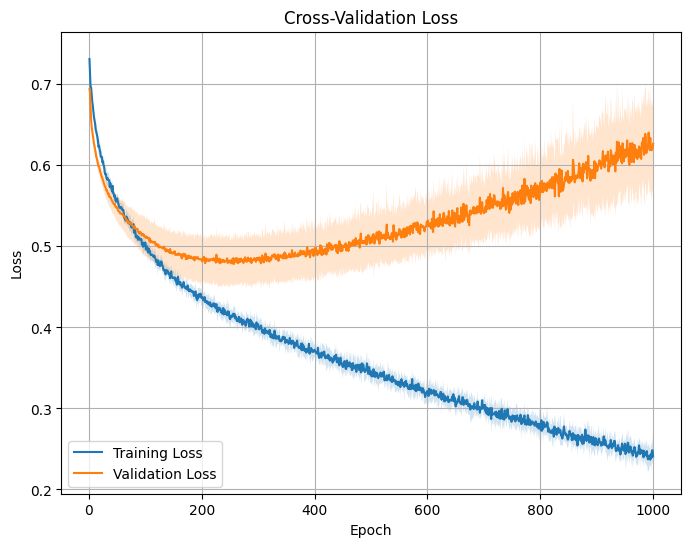

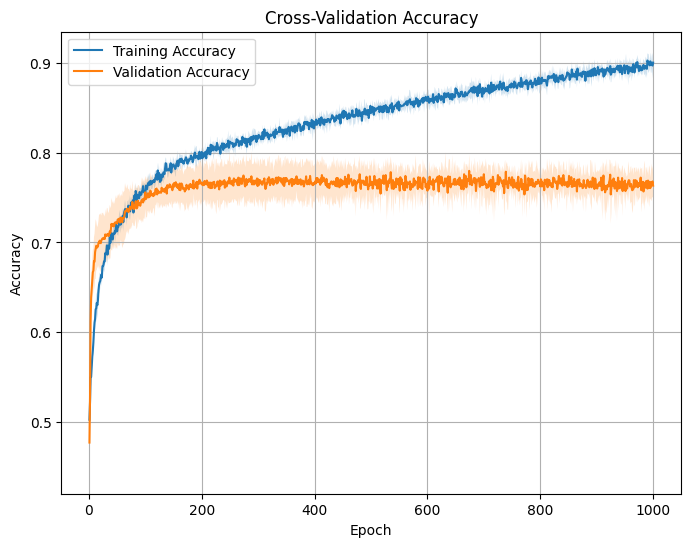

In [10]:
num_epochs = epochs
num_folds = k_folds

# Initialize arrays to store metrics
train_loss_all = np.zeros((num_folds, num_epochs))
val_loss_all = np.zeros((num_folds, num_epochs))
train_acc_all = np.zeros((num_folds, num_epochs))
val_acc_all = np.zeros((num_folds, num_epochs))

# Populate arrays with data from each fold
for i, history in enumerate(fold_histories):
    train_loss_all[i] = history['train_loss']
    val_loss_all[i] = history['val_loss']
    train_acc_all[i] = history['train_accuracy']
    val_acc_all[i] = history['val_accuracy']

# Compute mean and standard deviation
train_loss_mean = np.mean(train_loss_all, axis=0)
train_loss_std = np.std(train_loss_all, axis=0)
val_loss_mean = np.mean(val_loss_all, axis=0)
val_loss_std = np.std(val_loss_all, axis=0)

train_acc_mean = np.mean(train_acc_all, axis=0)
train_acc_std = np.std(train_acc_all, axis=0)
val_acc_mean = np.mean(val_acc_all, axis=0)
val_acc_std = np.std(val_acc_all, axis=0)

epochs_range = range(1, num_epochs + 1)

# Plot Loss
plt.figure(figsize=(8, 6))
plt.plot(epochs_range, train_loss_mean, label='Training Loss')
plt.fill_between(epochs_range, train_loss_mean - train_loss_std, train_loss_mean + train_loss_std, alpha=0.2)
plt.plot(epochs_range, val_loss_mean, label='Validation Loss')
plt.fill_between(epochs_range, val_loss_mean - val_loss_std, val_loss_mean + val_loss_std, alpha=0.2)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Cross-Validation Loss')
plt.legend()
plt.grid(True)
plt.show()

# Plot Accuracy
plt.figure(figsize=(8, 6))
plt.plot(epochs_range, train_acc_mean, label='Training Accuracy')
plt.fill_between(epochs_range, train_acc_mean - train_acc_std, train_acc_mean + train_acc_std, alpha=0.2)
plt.plot(epochs_range, val_acc_mean, label='Validation Accuracy')
plt.fill_between(epochs_range, val_acc_mean - val_acc_std, val_acc_mean + val_acc_std, alpha=0.2)
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Cross-Validation Accuracy')
plt.legend()
plt.grid(True)
plt.show()

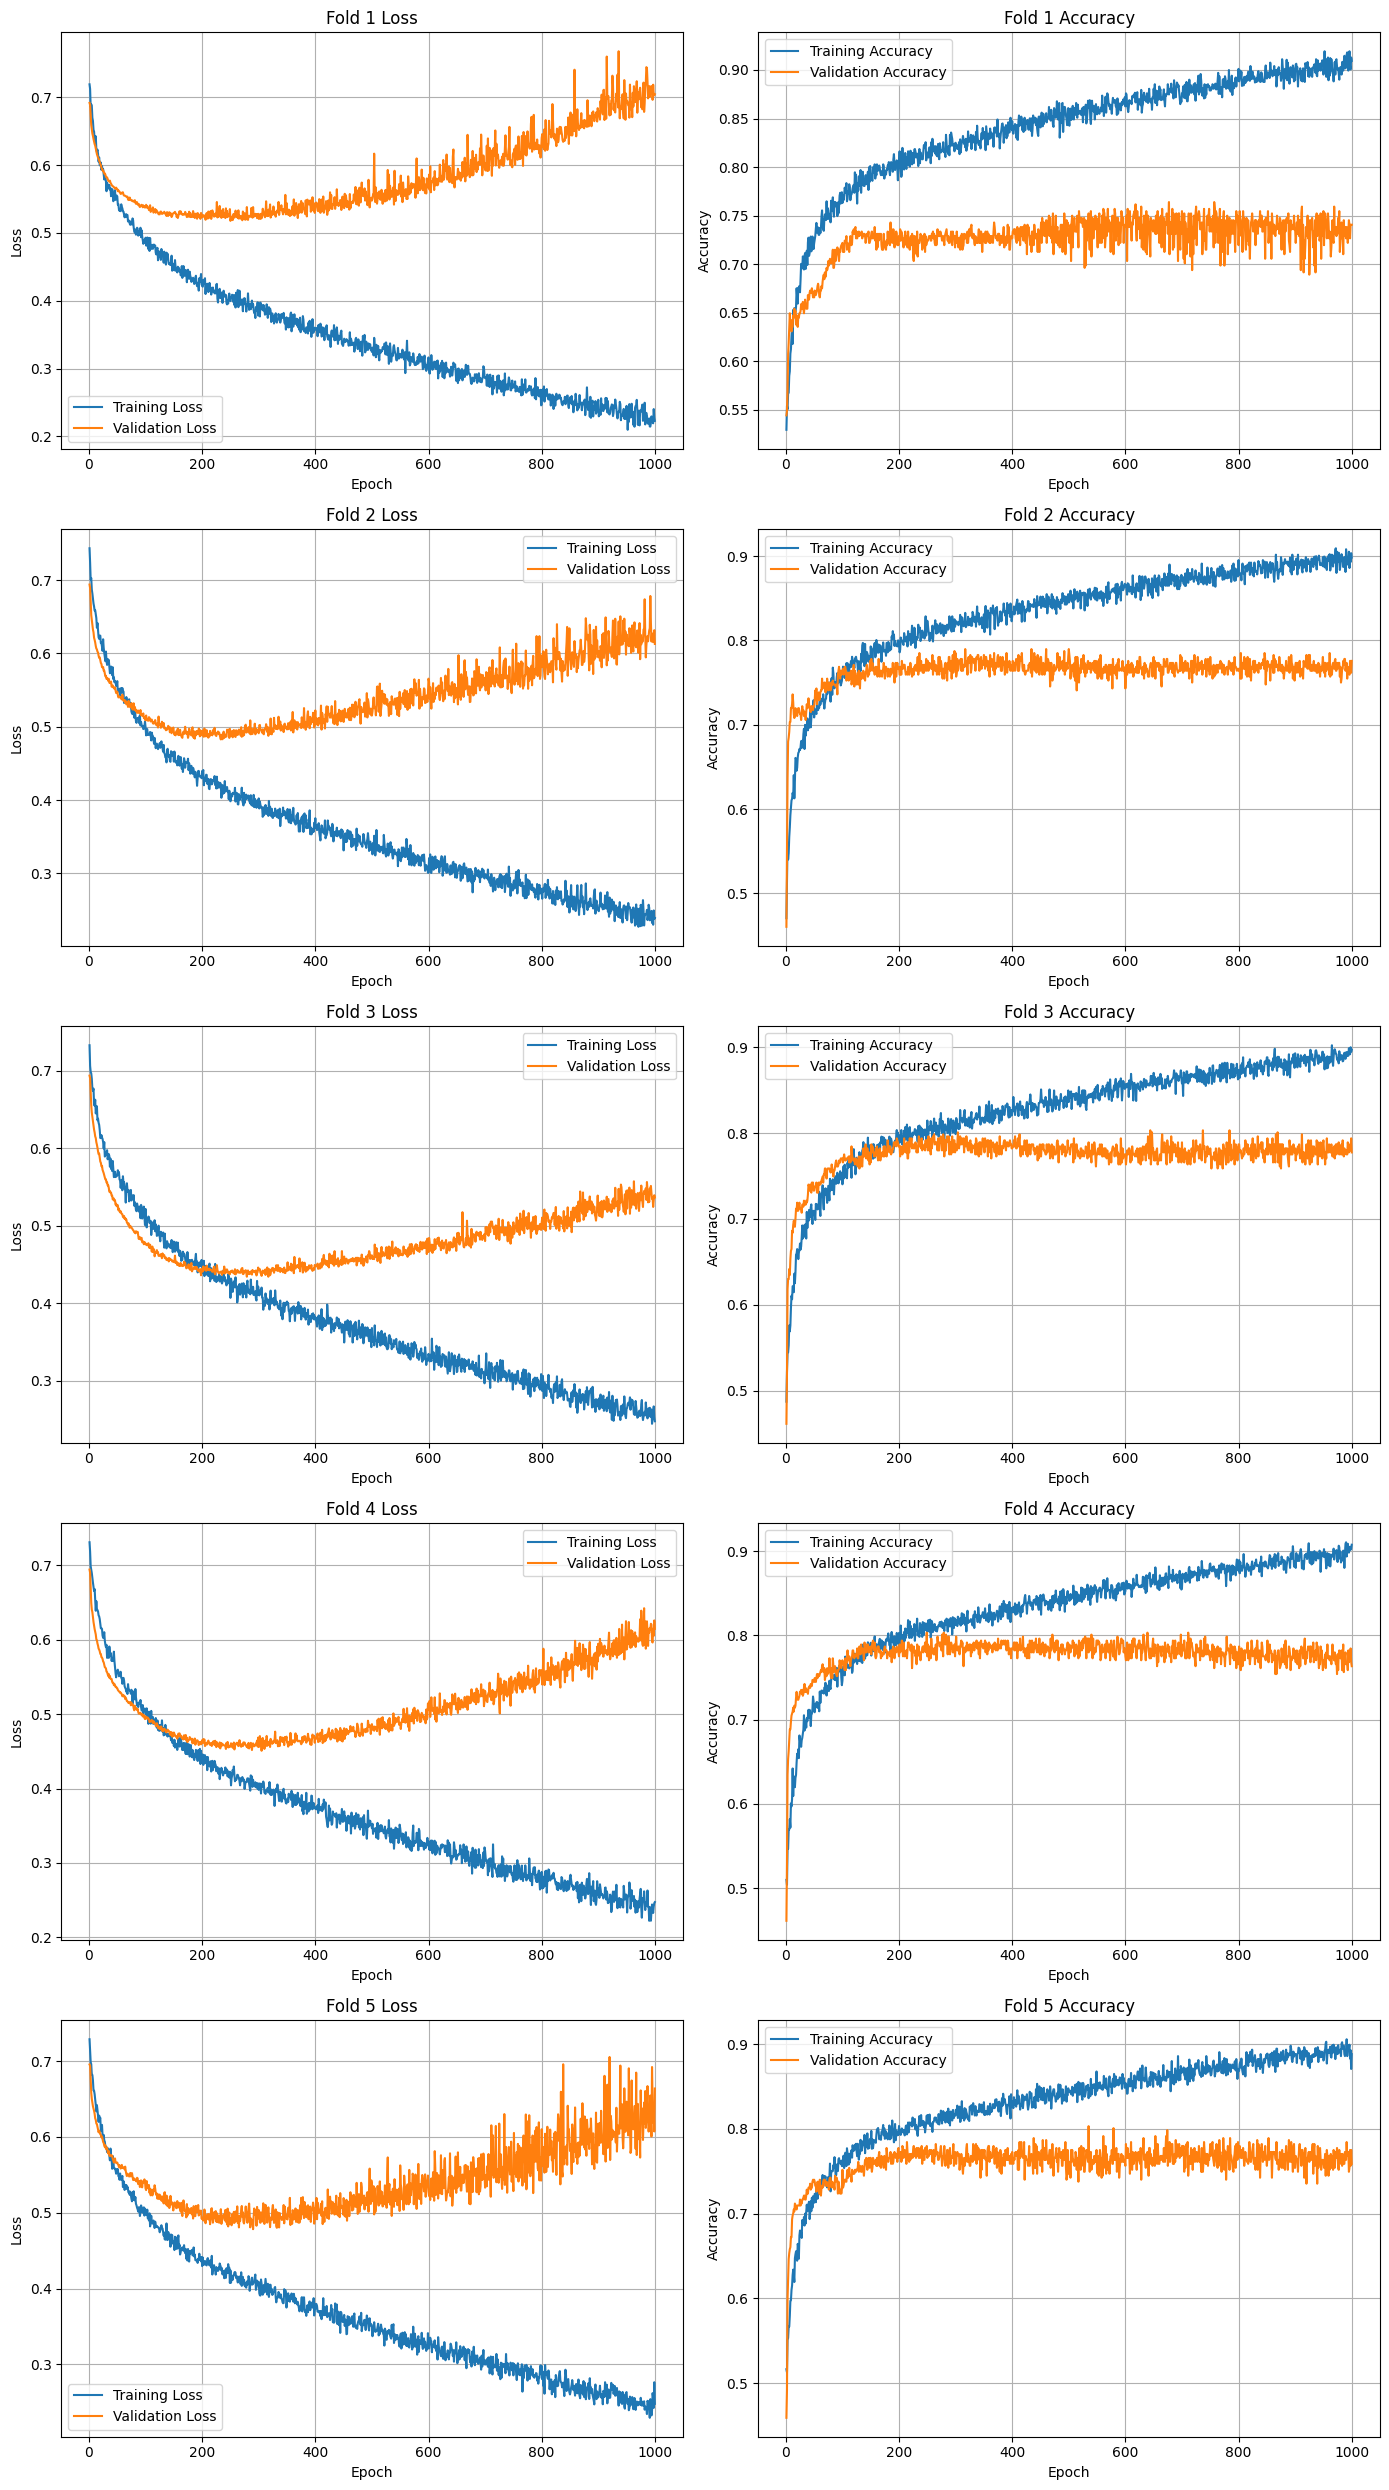

In [11]:
fig, axes = plt.subplots(nrows=k_folds, ncols=2, figsize=(14, 5 * k_folds))
axes = axes.reshape(k_folds, 2)

for i, history in enumerate(fold_histories):
    epochs_range = range(1, epochs + 1)
    
    ax_loss = axes[i, 0]
    ax_loss.plot(epochs_range, history["train_loss"], label='Training Loss')
    ax_loss.plot(epochs_range, history["val_loss"], label='Validation Loss')
    ax_loss.set_xlabel('Epoch')
    ax_loss.set_ylabel('Loss')
    ax_loss.set_title(f'Fold {i + 1} Loss')
    ax_loss.legend()
    ax_loss.grid(True)
    
    ax_acc = axes[i, 1]
    ax_acc.plot(epochs_range, history["train_accuracy"], label='Training Accuracy')
    ax_acc.plot(epochs_range, history["val_accuracy"], label='Validation Accuracy')
    ax_acc.set_xlabel('Epoch')
    ax_acc.set_ylabel('Accuracy')
    ax_acc.set_title(f'Fold {i + 1} Accuracy')
    ax_acc.legend()
    ax_acc.grid(True)

plt.tight_layout()
plt.show()

After experimenting a bit, according to this CV it seems like the (sub)optimal model is the one using Adam with learning rate 1e-5 and weight decay 1e-5. Moreover, it seems like a good stopping point is at 200, after which we observe overfitting. 

In [22]:
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)
epochs = 200
batch_size = 64
X_full_tensor = torch.tensor(X, dtype=torch.float32)
y_full_tensor = torch.tensor(y, dtype=torch.float32)
full_dataset = TensorDataset(X_full_tensor, y_full_tensor)
full_loader = DataLoader(full_dataset, batch_size=batch_size, shuffle=True)
final_model = BertweetBaseMLP(embedding_dim).to(device)
final_optimizer = optim.AdamW(final_model.parameters(), lr=1e-5, weight_decay=1e-5)
final_history = train_and_validate_model(final_model, full_loader, None, criterion, final_optimizer, device, epochs, seed, use_tqdm=False)
torch.save(final_model.state_dict(), "models/bertweet_base.pt")

Epoch 1/200
Training Loss: 0.7129, Accuracy: 0.5321
Epoch 2/200
Training Loss: 0.7088, Accuracy: 0.5452
Epoch 3/200
Training Loss: 0.6913, Accuracy: 0.5578
Epoch 4/200
Training Loss: 0.6890, Accuracy: 0.5601
Epoch 5/200
Training Loss: 0.6718, Accuracy: 0.5704
Epoch 6/200
Training Loss: 0.6631, Accuracy: 0.5868
Epoch 7/200
Training Loss: 0.6540, Accuracy: 0.6022
Epoch 8/200
Training Loss: 0.6515, Accuracy: 0.6125
Epoch 9/200
Training Loss: 0.6468, Accuracy: 0.6153
Epoch 10/200
Training Loss: 0.6447, Accuracy: 0.6083
Epoch 11/200
Training Loss: 0.6309, Accuracy: 0.6270
Epoch 12/200
Training Loss: 0.6240, Accuracy: 0.6434
Epoch 13/200
Training Loss: 0.6297, Accuracy: 0.6224
Epoch 14/200
Training Loss: 0.6193, Accuracy: 0.6476
Epoch 15/200
Training Loss: 0.6206, Accuracy: 0.6453
Epoch 16/200
Training Loss: 0.6175, Accuracy: 0.6467
Epoch 17/200
Training Loss: 0.6172, Accuracy: 0.6556
Epoch 18/200
Training Loss: 0.6037, Accuracy: 0.6603
Epoch 19/200
Training Loss: 0.6048, Accuracy: 0.6715
Ep

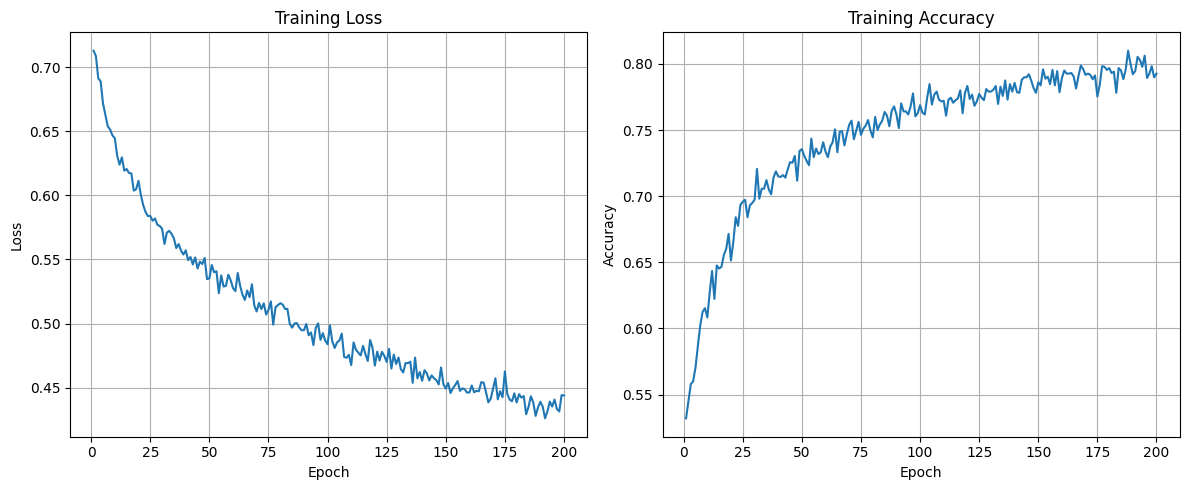

In [23]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1) 
plt.plot(range(1, epochs + 1), final_history["train_loss"])
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss')
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(range(1, epochs + 1), final_history["train_accuracy"])
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training Accuracy')
plt.grid(True)

plt.tight_layout()
plt.show()

## Testing

Let's test the model for the submission.

In [24]:
file_path = "processed_data/aggregated_embeddings_with_labels_test.pkl"
merged_df_test = pd.read_pickle(file_path)
X_test = np.vstack(merged_df_test["aggregated_embedding"].values)

In [25]:
merged_df_test

,ID,aggregated_embedding,MatchID
0,15_0,"[-0.005626861, 0.17002444, 0.1560707, -0.07122...",15
1,15_1,"[-0.012398133, 0.16987626, 0.15416442, -0.0715...",15
2,15_10,"[-0.0063685165, 0.17705764, 0.14571677, -0.061...",15
3,15_100,"[-0.028167112, 0.21267831, 0.11889246, -0.0327...",15
4,15_101,"[-0.021408508, 0.20869574, 0.12005638, -0.0342...",15
...,...,...,...
511,9_95,"[-0.06389925, 0.15774356, 0.10894526, -0.06712...",9
512,9_96,"[-0.06254904, 0.16254315, 0.10645582, -0.07547...",9
513,9_97,"[-0.06544371, 0.15834767, 0.1077392, -0.078381...",9
514,9_98,"[-0.061433755, 0.15302086, 0.0968332, -0.06357...",9


In [26]:
X_test.shape

(516, 768)

In [27]:
X_test_tensor = torch.tensor(X_test, dtype=torch.float32).to(device)

In [28]:
# embedding_dim = X_test.shape[1]
# final_model = BertweetBaseMLP(embedding_dim)
# final_model.load_state_dict(torch.load("models/bertweet_base.pt"))
# final_model = final_model.to(device)

In [29]:
final_model.eval()
with torch.no_grad():
    logits = final_model(X_test_tensor).squeeze()  
    predictions = (torch.sigmoid(logits) >= 0.5).int().cpu().numpy()
    
final_df = pd.DataFrame({
    "ID": merged_df_test["ID"],
    "EventType": predictions  # Add predictions as EventType
})    

In [30]:
final_df

,ID,EventType
0,15_0,1
1,15_1,1
2,15_10,0
3,15_100,1
4,15_101,1
...,...,...
511,9_95,0
512,9_96,0
513,9_97,0
514,9_98,0


In [31]:
final_df.to_csv("predictions/bertweet_base_predictions.csv", index=False)

# Preprocessed Data

## Training

In [2]:
file_path = "processed_data/aggregated_processed_embeddings_with_labels.pkl"
merged_df = pd.read_pickle(file_path)
X = np.vstack(merged_df["aggregated_embedding"].values)
y = merged_df["EventType"].values

In [3]:
merged_df

,ID,aggregated_embedding,EventType
0,0_0,"[0.0077453065, 0.17549586, 0.16632368, -0.0875...",0
1,0_1,"[0.0014848565, 0.19115415, 0.16461384, -0.0782...",0
2,0_10,"[-0.014252684, 0.18220407, 0.18043293, -0.0904...",1
3,0_100,"[0.016221795, 0.20151705, 0.1643491, -0.082726...",1
4,0_101,"[0.020098286, 0.1949107, 0.17537716, -0.080492...",1
...,...,...,...
2132,8_95,"[-0.04038633, 0.18724294, 0.14488834, -0.08550...",0
2133,8_96,"[-0.039810836, 0.18430696, 0.164863, -0.102904...",1
2134,8_97,"[-0.03178892, 0.17811145, 0.15852357, -0.09098...",1
2135,8_98,"[-0.051116683, 0.18360771, 0.15212744, -0.0881...",0


In [3]:
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)
embedding_dim = X.shape[1]
batch_size = 64
k_folds = 5
skf = StratifiedKFold(n_splits=k_folds, shuffle=True, random_state=seed)
criterion = nn.BCEWithLogitsLoss()

In [ ]:
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)

epochs = 1000
fold_histories = []
fold_accuracies = []

for fold, (train_idx, val_idx) in enumerate(skf.split(X, y)):
    print(f'Fold {fold + 1}/{k_folds}')
    
    X_train_fold, X_val_fold = X[train_idx], X[val_idx]
    y_train_fold, y_val_fold = y[train_idx], y[val_idx]
    
    X_train_tensor = torch.tensor(X_train_fold, dtype=torch.float32)
    y_train_tensor = torch.tensor(y_train_fold, dtype=torch.float32)
    X_val_tensor = torch.tensor(X_val_fold, dtype=torch.float32)
    y_val_tensor = torch.tensor(y_val_fold, dtype=torch.float32)
    
    train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_dataset = TensorDataset(X_val_tensor, y_val_tensor)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
    
    model = BertweetBaseMLP(embedding_dim).to(device)
    optimizer = optim.AdamW(model.parameters(), lr=1e-5, weight_decay=1e-5)
    
    history = train_and_validate_model(model, train_loader, val_loader, criterion, optimizer, device, epochs, seed, use_tqdm=False)
    fold_histories.append(history)
    
    val_accuracy = history['val_accuracy'][-1]
    fold_accuracies.append(val_accuracy)
    
    print(f'Fold {fold + 1} Validation Accuracy: {val_accuracy:.4f}')

Fold 1/5
Epoch 1/1000
Training Loss: 0.7244, Accuracy: 0.5272
Validation Loss: 0.6923, Accuracy: 0.5397
Epoch 2/1000
Training Loss: 0.7062, Accuracy: 0.5453
Validation Loss: 0.6920, Accuracy: 0.5164
Epoch 3/1000
Training Loss: 0.6983, Accuracy: 0.5559
Validation Loss: 0.6800, Accuracy: 0.6168
Epoch 4/1000
Training Loss: 0.6873, Accuracy: 0.5647
Validation Loss: 0.6622, Accuracy: 0.6238
Epoch 5/1000
Training Loss: 0.6895, Accuracy: 0.5647
Validation Loss: 0.6559, Accuracy: 0.5981
Epoch 6/1000
Training Loss: 0.6654, Accuracy: 0.5951
Validation Loss: 0.6526, Accuracy: 0.6005
Epoch 7/1000
Training Loss: 0.6725, Accuracy: 0.5922
Validation Loss: 0.6481, Accuracy: 0.6192
Epoch 8/1000
Training Loss: 0.6478, Accuracy: 0.6115
Validation Loss: 0.6443, Accuracy: 0.6215
Epoch 9/1000
Training Loss: 0.6522, Accuracy: 0.6039
Validation Loss: 0.6408, Accuracy: 0.6238
Epoch 10/1000
Training Loss: 0.6416, Accuracy: 0.6144
Validation Loss: 0.6376, Accuracy: 0.6262
Epoch 11/1000
Training Loss: 0.6356, Acc

In [5]:
average_accuracy = sum(fold_accuracies) / k_folds
print(f'Average Validation Accuracy: {average_accuracy:.4f}')

Average Validation Accuracy: 0.7557


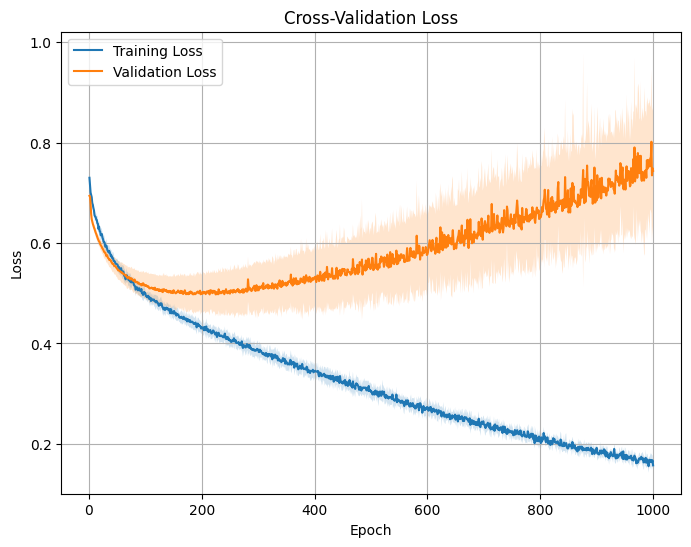

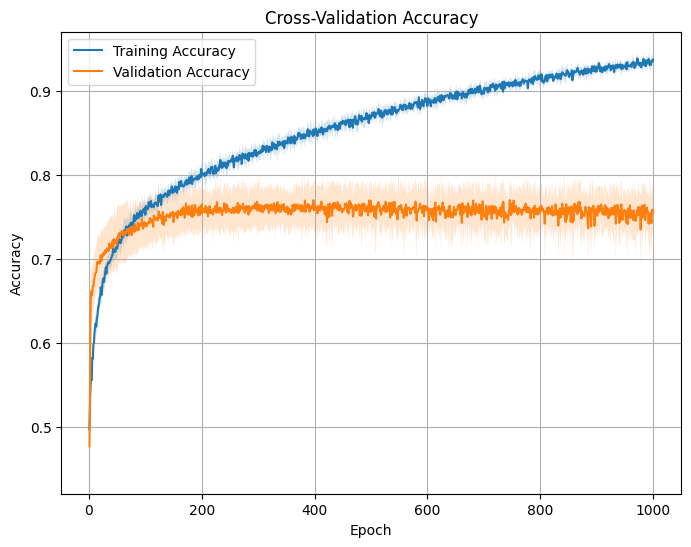

In [6]:
num_epochs = epochs
num_folds = k_folds

# Initialize arrays to store metrics
train_loss_all = np.zeros((num_folds, num_epochs))
val_loss_all = np.zeros((num_folds, num_epochs))
train_acc_all = np.zeros((num_folds, num_epochs))
val_acc_all = np.zeros((num_folds, num_epochs))

# Populate arrays with data from each fold
for i, history in enumerate(fold_histories):
    train_loss_all[i] = history['train_loss']
    val_loss_all[i] = history['val_loss']
    train_acc_all[i] = history['train_accuracy']
    val_acc_all[i] = history['val_accuracy']

# Compute mean and standard deviation
train_loss_mean = np.mean(train_loss_all, axis=0)
train_loss_std = np.std(train_loss_all, axis=0)
val_loss_mean = np.mean(val_loss_all, axis=0)
val_loss_std = np.std(val_loss_all, axis=0)

train_acc_mean = np.mean(train_acc_all, axis=0)
train_acc_std = np.std(train_acc_all, axis=0)
val_acc_mean = np.mean(val_acc_all, axis=0)
val_acc_std = np.std(val_acc_all, axis=0)

epochs_range = range(1, num_epochs + 1)

# Plot Loss
plt.figure(figsize=(8, 6))
plt.plot(epochs_range, train_loss_mean, label='Training Loss')
plt.fill_between(epochs_range, train_loss_mean - train_loss_std, train_loss_mean + train_loss_std, alpha=0.2)
plt.plot(epochs_range, val_loss_mean, label='Validation Loss')
plt.fill_between(epochs_range, val_loss_mean - val_loss_std, val_loss_mean + val_loss_std, alpha=0.2)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Cross-Validation Loss')
plt.legend()
plt.grid(True)
plt.show()

# Plot Accuracy
plt.figure(figsize=(8, 6))
plt.plot(epochs_range, train_acc_mean, label='Training Accuracy')
plt.fill_between(epochs_range, train_acc_mean - train_acc_std, train_acc_mean + train_acc_std, alpha=0.2)
plt.plot(epochs_range, val_acc_mean, label='Validation Accuracy')
plt.fill_between(epochs_range, val_acc_mean - val_acc_std, val_acc_mean + val_acc_std, alpha=0.2)
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Cross-Validation Accuracy')
plt.legend()
plt.grid(True)
plt.show()

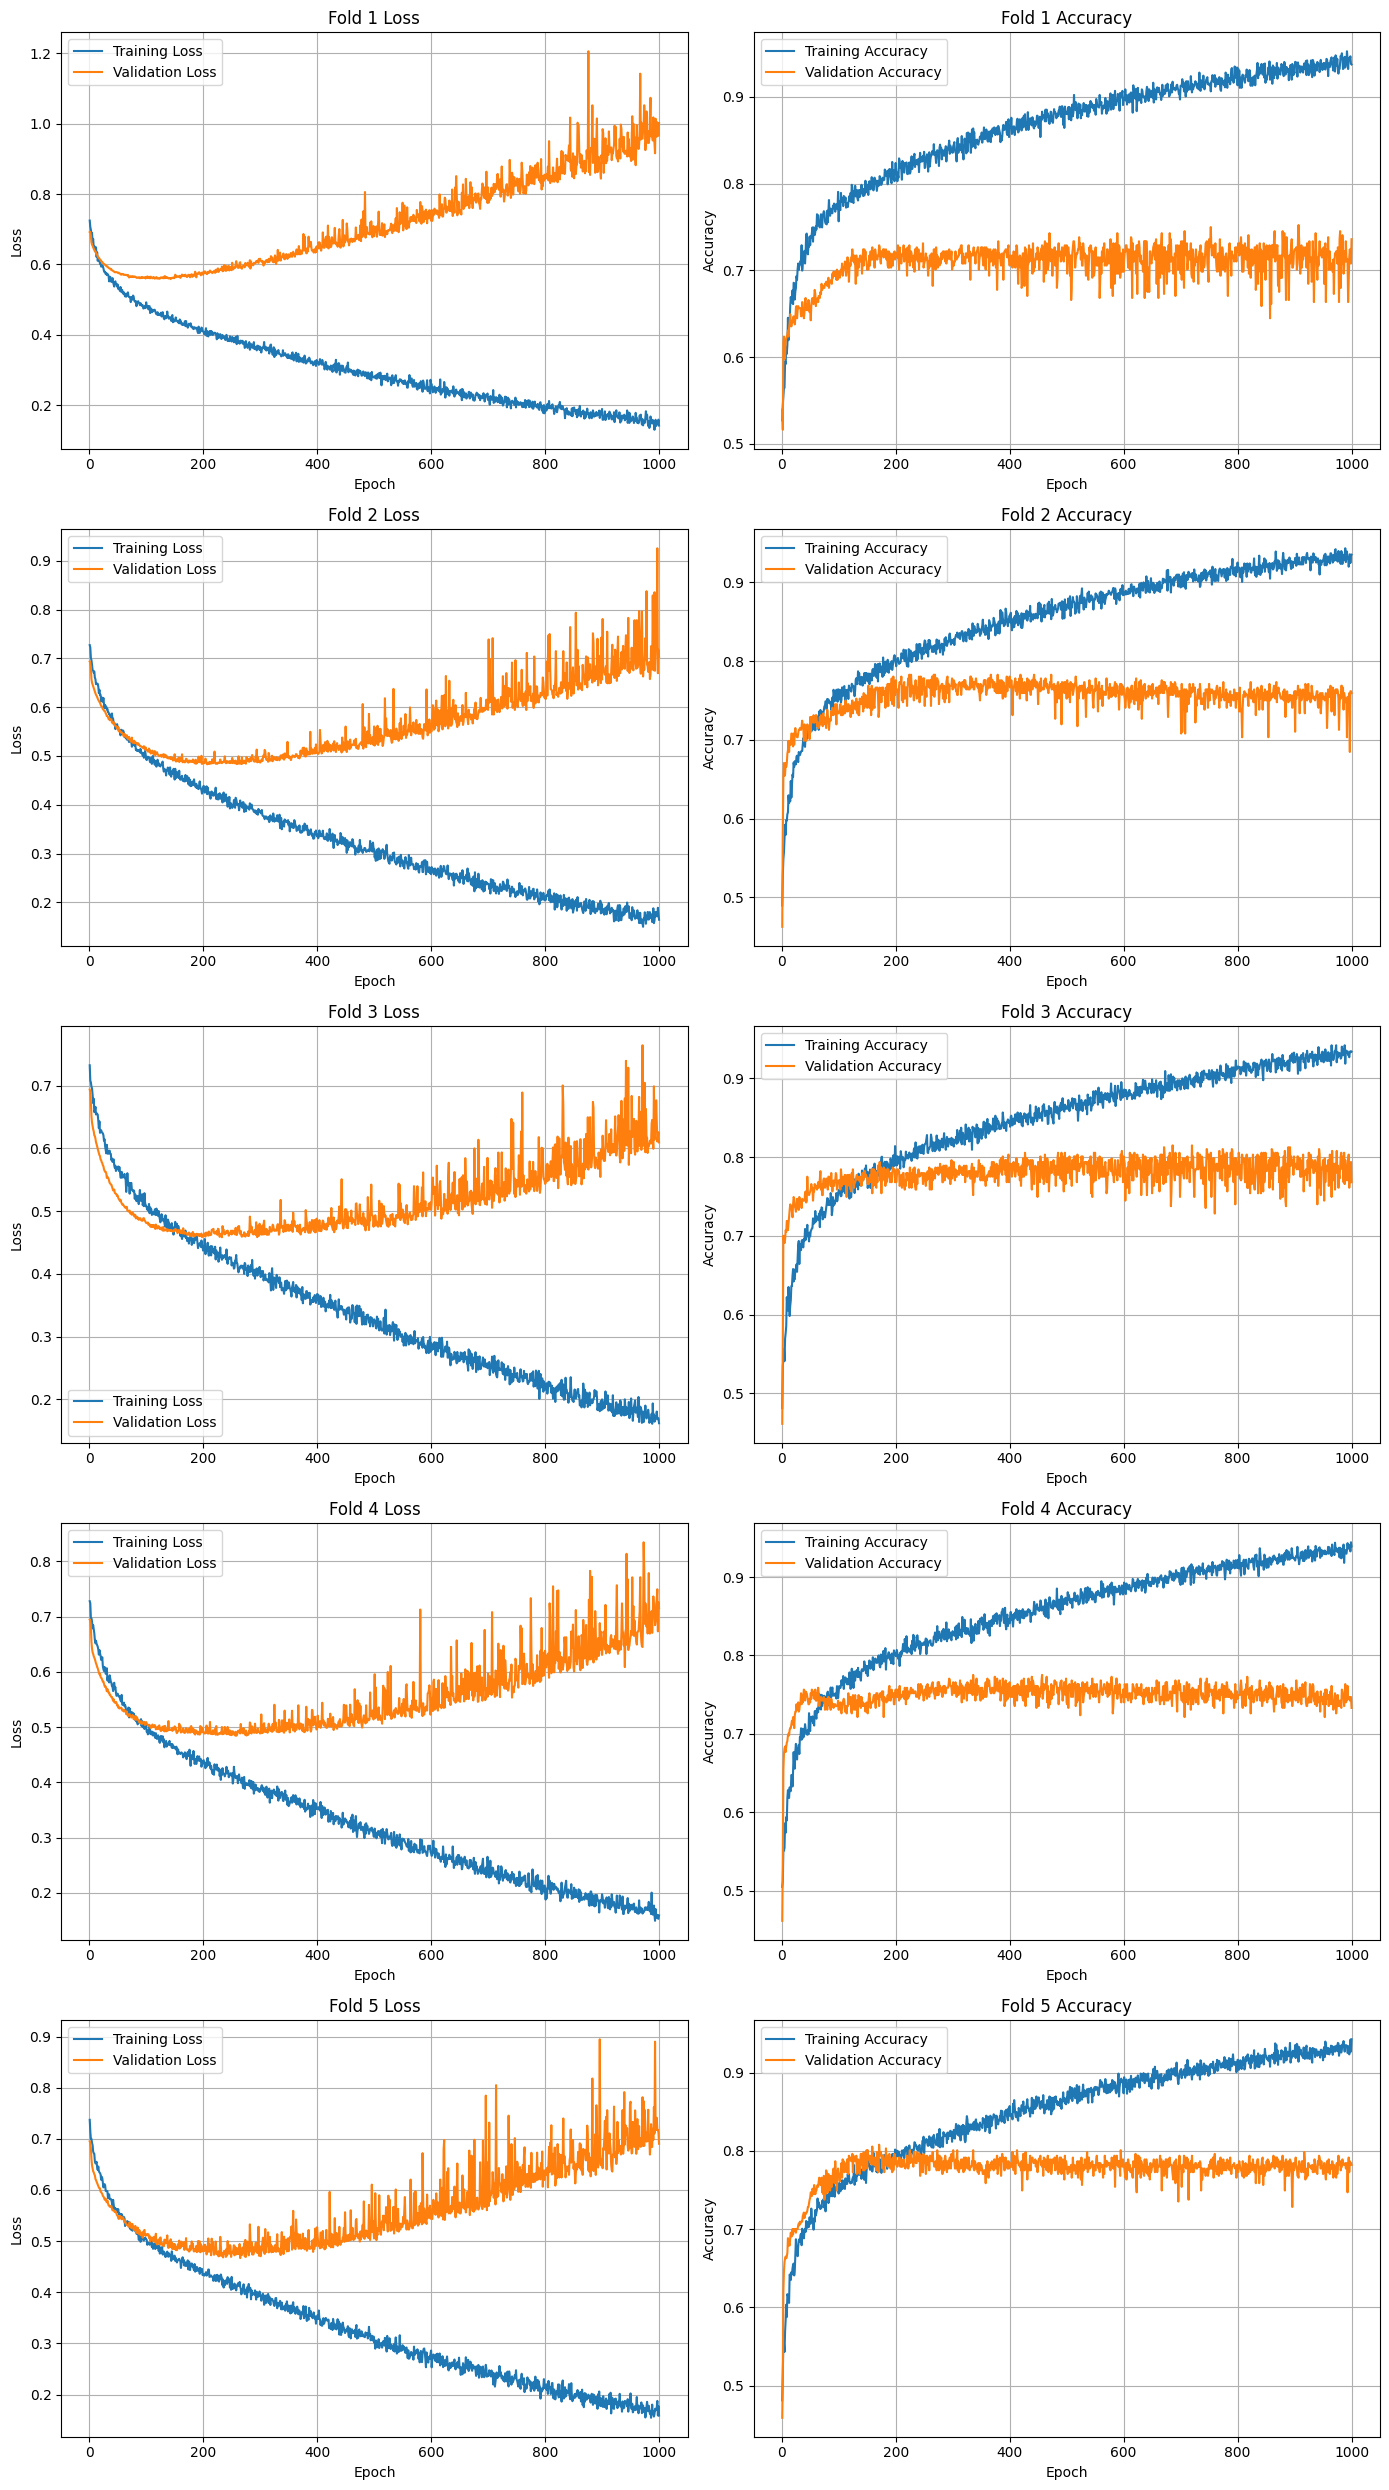

In [7]:
fig, axes = plt.subplots(nrows=k_folds, ncols=2, figsize=(14, 5 * k_folds))
axes = axes.reshape(k_folds, 2)

for i, history in enumerate(fold_histories):
    epochs_range = range(1, epochs + 1)
    
    ax_loss = axes[i, 0]
    ax_loss.plot(epochs_range, history["train_loss"], label='Training Loss')
    ax_loss.plot(epochs_range, history["val_loss"], label='Validation Loss')
    ax_loss.set_xlabel('Epoch')
    ax_loss.set_ylabel('Loss')
    ax_loss.set_title(f'Fold {i + 1} Loss')
    ax_loss.legend()
    ax_loss.grid(True)
    
    ax_acc = axes[i, 1]
    ax_acc.plot(epochs_range, history["train_accuracy"], label='Training Accuracy')
    ax_acc.plot(epochs_range, history["val_accuracy"], label='Validation Accuracy')
    ax_acc.set_xlabel('Epoch')
    ax_acc.set_ylabel('Accuracy')
    ax_acc.set_title(f'Fold {i + 1} Accuracy')
    ax_acc.legend()
    ax_acc.grid(True)

plt.tight_layout()
plt.show()

In non preprocessed data we had an avg val acc of 0.7632, so here we have worsened the situation. However, it's probably because it overfits faster, so the large number of epochs makes it worse. Again, a good stopping point seems at 200 epochs.

In [8]:
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)
epochs = 200
batch_size = 64
X_full_tensor = torch.tensor(X, dtype=torch.float32)
y_full_tensor = torch.tensor(y, dtype=torch.float32)
full_dataset = TensorDataset(X_full_tensor, y_full_tensor)
full_loader = DataLoader(full_dataset, batch_size=batch_size, shuffle=True)
final_model = BertweetBaseMLP(embedding_dim).to(device)
final_optimizer = optim.AdamW(final_model.parameters(), lr=1e-5, weight_decay=1e-5)
final_history = train_and_validate_model(final_model, full_loader, None, criterion, final_optimizer, device, epochs, seed, use_tqdm=False)
torch.save(final_model.state_dict(), "models/bertweet_base_preprocessed.pt")

Epoch 1/200
Training Loss: 0.7220, Accuracy: 0.5316
Epoch 2/200
Training Loss: 0.7084, Accuracy: 0.5508
Epoch 3/200
Training Loss: 0.6953, Accuracy: 0.5648
Epoch 4/200
Training Loss: 0.6861, Accuracy: 0.5784
Epoch 5/200
Training Loss: 0.6756, Accuracy: 0.5826
Epoch 6/200
Training Loss: 0.6641, Accuracy: 0.5873
Epoch 7/200
Training Loss: 0.6555, Accuracy: 0.5990
Epoch 8/200
Training Loss: 0.6495, Accuracy: 0.6125
Epoch 9/200
Training Loss: 0.6464, Accuracy: 0.6121
Epoch 10/200
Training Loss: 0.6341, Accuracy: 0.6275
Epoch 11/200
Training Loss: 0.6356, Accuracy: 0.6275
Epoch 12/200
Training Loss: 0.6330, Accuracy: 0.6420
Epoch 13/200
Training Loss: 0.6331, Accuracy: 0.6373
Epoch 14/200
Training Loss: 0.6255, Accuracy: 0.6383
Epoch 15/200
Training Loss: 0.6227, Accuracy: 0.6589
Epoch 16/200
Training Loss: 0.6201, Accuracy: 0.6476
Epoch 17/200
Training Loss: 0.6087, Accuracy: 0.6659
Epoch 18/200
Training Loss: 0.5975, Accuracy: 0.6781
Epoch 19/200
Training Loss: 0.6045, Accuracy: 0.6682
Ep

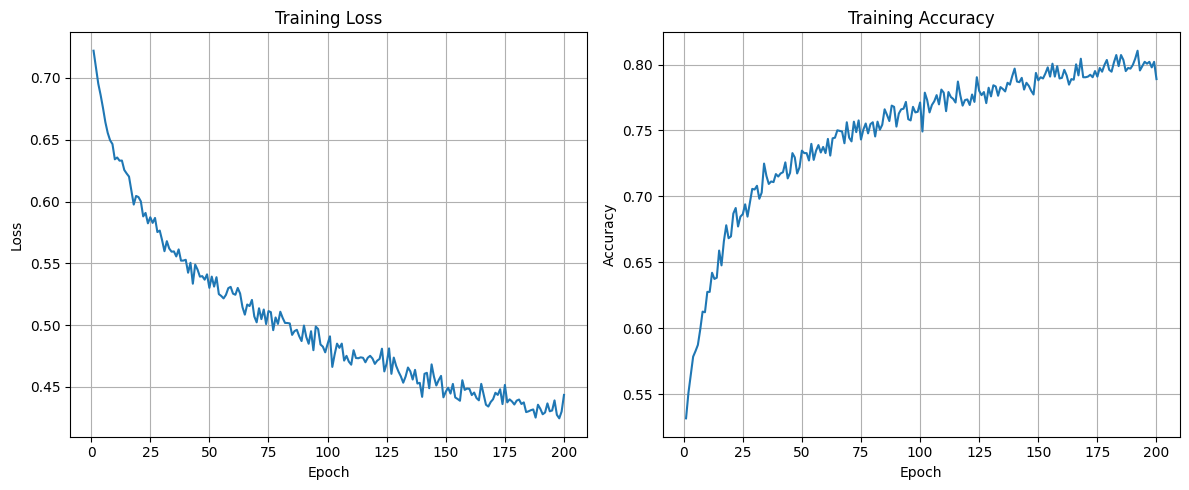

In [9]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1) 
plt.plot(range(1, epochs + 1), final_history["train_loss"])
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss')
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(range(1, epochs + 1), final_history["train_accuracy"])
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training Accuracy')
plt.grid(True)

plt.tight_layout()
plt.show()

## Testing

In [10]:
file_path = "processed_data/aggregated_processed_embeddings_with_labels_test.pkl"
merged_df_test = pd.read_pickle(file_path)
X_test = np.vstack(merged_df_test["aggregated_embedding"].values)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32).to(device)

In [ ]:
# embedding_dim = X_test.shape[1]
# final_model = BertweetBaseMLP(embedding_dim)
# final_model.load_state_dict(torch.load("models/bertweet_base_preprocessed.pt"))
# final_model = final_model.to(device)

In [11]:
final_model.eval()
with torch.no_grad():
    logits = final_model(X_test_tensor).squeeze()  
    predictions = (torch.sigmoid(logits) >= 0.5).int().cpu().numpy()
    
final_df = pd.DataFrame({
    "ID": merged_df_test["ID"],
    "EventType": predictions  # Add predictions as EventType
})    

In [12]:
final_df

,ID,EventType
0,15_0,1
1,15_1,1
2,15_10,0
3,15_100,1
4,15_101,1
...,...,...
511,9_95,0
512,9_96,0
513,9_97,0
514,9_98,1


In [13]:
final_df.to_csv("predictions/bertweet_base_preprocessed_predictions.csv", index=False)

# Preprocessed Data - No Teams

## Training

In [3]:
file_path = "processed_data/aggregated_processed_no_teams_embeddings_with_labels.pkl"
merged_df = pd.read_pickle(file_path)
X = np.vstack(merged_df["aggregated_embedding"].values)
y = merged_df["EventType"].values

In [4]:
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)
embedding_dim = X.shape[1]
batch_size = 64
k_folds = 5
skf = StratifiedKFold(n_splits=k_folds, shuffle=True, random_state=seed)
criterion = nn.BCEWithLogitsLoss()

In [5]:
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)

epochs = 1000
fold_histories = []
fold_accuracies = []

for fold, (train_idx, val_idx) in enumerate(skf.split(X, y)):
    print(f'Fold {fold + 1}/{k_folds}')
    
    X_train_fold, X_val_fold = X[train_idx], X[val_idx]
    y_train_fold, y_val_fold = y[train_idx], y[val_idx]
    
    X_train_tensor = torch.tensor(X_train_fold, dtype=torch.float32)
    y_train_tensor = torch.tensor(y_train_fold, dtype=torch.float32)
    X_val_tensor = torch.tensor(X_val_fold, dtype=torch.float32)
    y_val_tensor = torch.tensor(y_val_fold, dtype=torch.float32)
    
    train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_dataset = TensorDataset(X_val_tensor, y_val_tensor)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
    
    model = BertweetBaseMLP(embedding_dim).to(device)
    optimizer = optim.AdamW(model.parameters(), lr=1e-5, weight_decay=1e-5)
    
    history = train_and_validate_model(model, train_loader, val_loader, criterion, optimizer, device, epochs, seed, use_tqdm=False)
    fold_histories.append(history)
    
    val_accuracy = history['val_accuracy'][-1]
    fold_accuracies.append(val_accuracy)
    
    print(f'Fold {fold + 1} Validation Accuracy: {val_accuracy:.4f}')

Fold 1/5
Epoch 1/1000
Training Loss: 0.7066, Accuracy: 0.5173
Validation Loss: 0.6914, Accuracy: 0.5397
Epoch 2/1000
Training Loss: 0.6922, Accuracy: 0.5395
Validation Loss: 0.6903, Accuracy: 0.5421
Epoch 3/1000
Training Loss: 0.6789, Accuracy: 0.5746
Validation Loss: 0.6778, Accuracy: 0.6262
Epoch 4/1000
Training Loss: 0.6768, Accuracy: 0.5676
Validation Loss: 0.6462, Accuracy: 0.6168
Epoch 5/1000
Training Loss: 0.6748, Accuracy: 0.5764
Validation Loss: 0.6310, Accuracy: 0.6472
Epoch 6/1000
Training Loss: 0.6557, Accuracy: 0.5951
Validation Loss: 0.6270, Accuracy: 0.6589
Epoch 7/1000
Training Loss: 0.6606, Accuracy: 0.6044
Validation Loss: 0.6192, Accuracy: 0.6659
Epoch 8/1000
Training Loss: 0.6368, Accuracy: 0.6173
Validation Loss: 0.6172, Accuracy: 0.6636
Epoch 9/1000
Training Loss: 0.6446, Accuracy: 0.6109
Validation Loss: 0.6113, Accuracy: 0.6636
Epoch 10/1000
Training Loss: 0.6226, Accuracy: 0.6635
Validation Loss: 0.6069, Accuracy: 0.6706
Epoch 11/1000
Training Loss: 0.6168, Acc

In [6]:
average_accuracy = sum(fold_accuracies) / k_folds
print(f'Average Validation Accuracy: {average_accuracy:.4f}')

Average Validation Accuracy: 0.7450


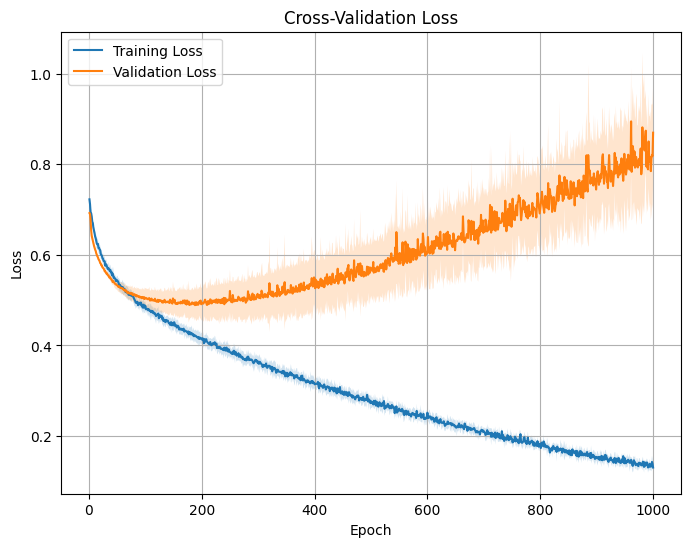

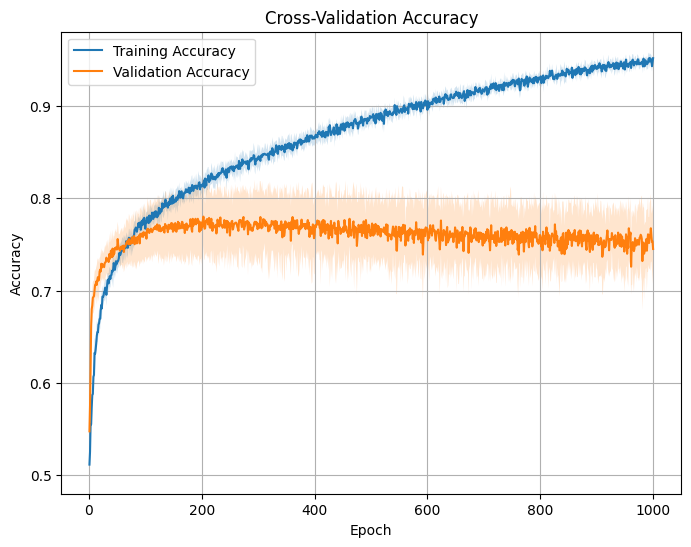

In [7]:
num_epochs = epochs
num_folds = k_folds

# Initialize arrays to store metrics
train_loss_all = np.zeros((num_folds, num_epochs))
val_loss_all = np.zeros((num_folds, num_epochs))
train_acc_all = np.zeros((num_folds, num_epochs))
val_acc_all = np.zeros((num_folds, num_epochs))

# Populate arrays with data from each fold
for i, history in enumerate(fold_histories):
    train_loss_all[i] = history['train_loss']
    val_loss_all[i] = history['val_loss']
    train_acc_all[i] = history['train_accuracy']
    val_acc_all[i] = history['val_accuracy']

# Compute mean and standard deviation
train_loss_mean = np.mean(train_loss_all, axis=0)
train_loss_std = np.std(train_loss_all, axis=0)
val_loss_mean = np.mean(val_loss_all, axis=0)
val_loss_std = np.std(val_loss_all, axis=0)

train_acc_mean = np.mean(train_acc_all, axis=0)
train_acc_std = np.std(train_acc_all, axis=0)
val_acc_mean = np.mean(val_acc_all, axis=0)
val_acc_std = np.std(val_acc_all, axis=0)

epochs_range = range(1, num_epochs + 1)

# Plot Loss
plt.figure(figsize=(8, 6))
plt.plot(epochs_range, train_loss_mean, label='Training Loss')
plt.fill_between(epochs_range, train_loss_mean - train_loss_std, train_loss_mean + train_loss_std, alpha=0.2)
plt.plot(epochs_range, val_loss_mean, label='Validation Loss')
plt.fill_between(epochs_range, val_loss_mean - val_loss_std, val_loss_mean + val_loss_std, alpha=0.2)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Cross-Validation Loss')
plt.legend()
plt.grid(True)
plt.show()

# Plot Accuracy
plt.figure(figsize=(8, 6))
plt.plot(epochs_range, train_acc_mean, label='Training Accuracy')
plt.fill_between(epochs_range, train_acc_mean - train_acc_std, train_acc_mean + train_acc_std, alpha=0.2)
plt.plot(epochs_range, val_acc_mean, label='Validation Accuracy')
plt.fill_between(epochs_range, val_acc_mean - val_acc_std, val_acc_mean + val_acc_std, alpha=0.2)
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Cross-Validation Accuracy')
plt.legend()
plt.grid(True)
plt.show()

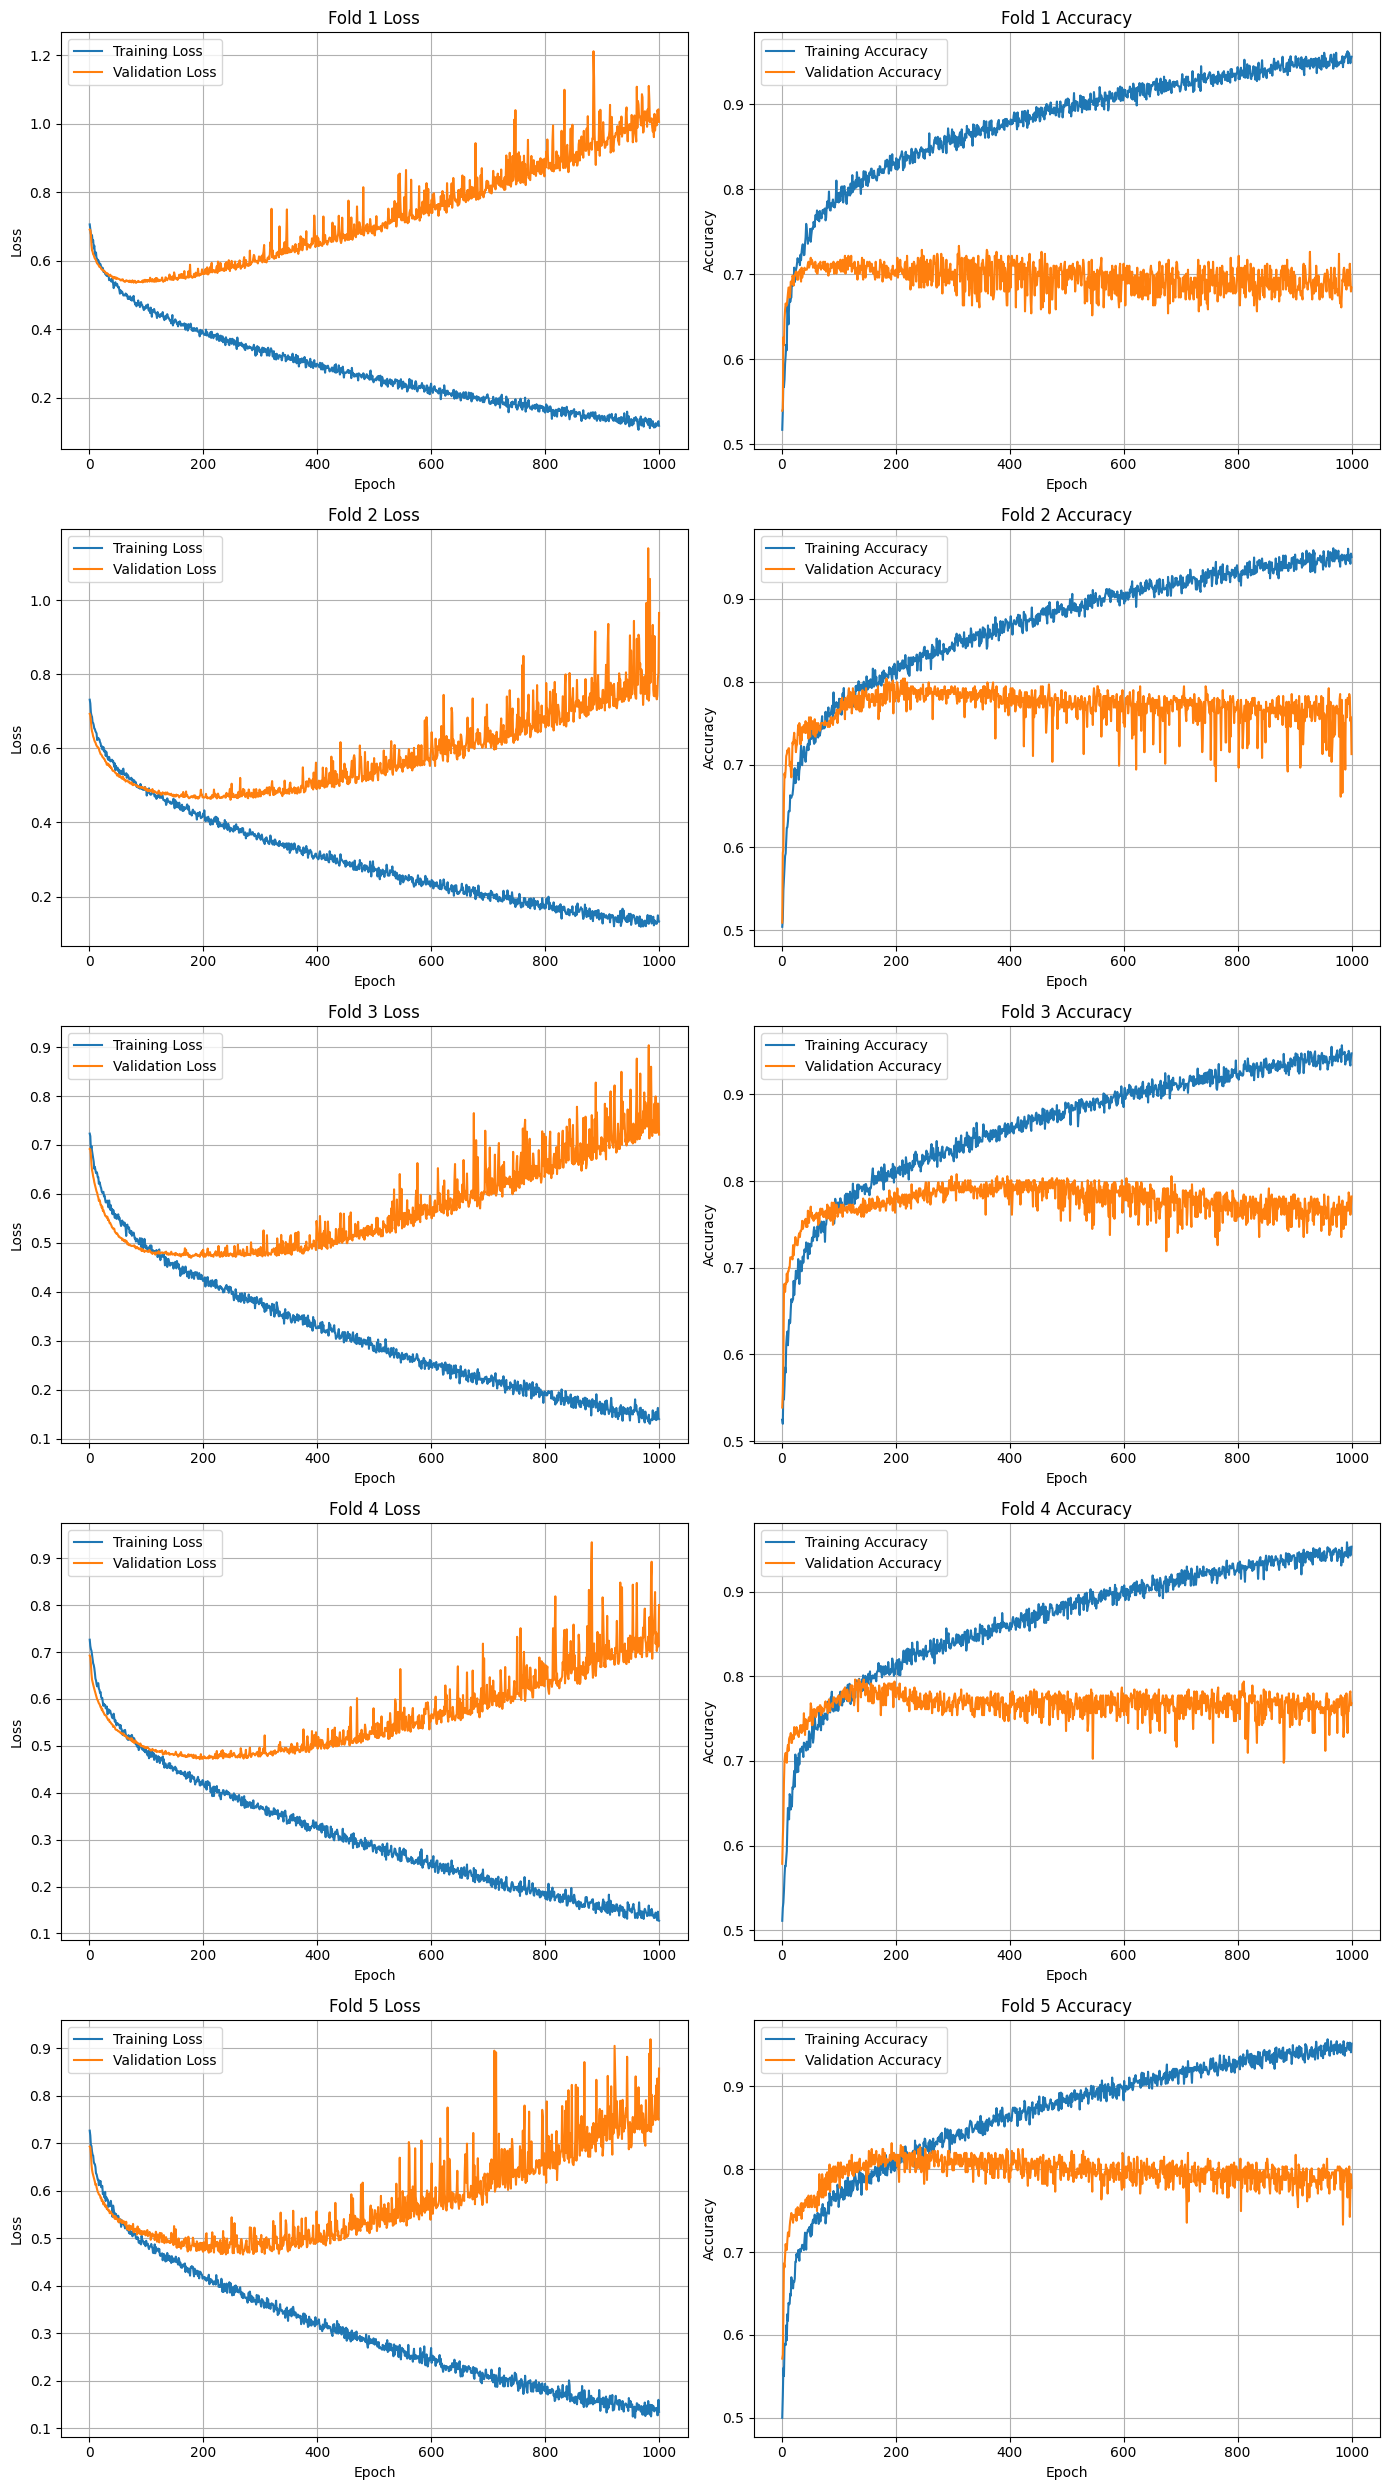

In [8]:
fig, axes = plt.subplots(nrows=k_folds, ncols=2, figsize=(14, 5 * k_folds))
axes = axes.reshape(k_folds, 2)

for i, history in enumerate(fold_histories):
    epochs_range = range(1, epochs + 1)
    
    ax_loss = axes[i, 0]
    ax_loss.plot(epochs_range, history["train_loss"], label='Training Loss')
    ax_loss.plot(epochs_range, history["val_loss"], label='Validation Loss')
    ax_loss.set_xlabel('Epoch')
    ax_loss.set_ylabel('Loss')
    ax_loss.set_title(f'Fold {i + 1} Loss')
    ax_loss.legend()
    ax_loss.grid(True)
    
    ax_acc = axes[i, 1]
    ax_acc.plot(epochs_range, history["train_accuracy"], label='Training Accuracy')
    ax_acc.plot(epochs_range, history["val_accuracy"], label='Validation Accuracy')
    ax_acc.set_xlabel('Epoch')
    ax_acc.set_ylabel('Accuracy')
    ax_acc.set_title(f'Fold {i + 1} Accuracy')
    ax_acc.legend()
    ax_acc.grid(True)

plt.tight_layout()
plt.show()

train for 150 epochs

In [9]:
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)
epochs = 150
batch_size = 64
X_full_tensor = torch.tensor(X, dtype=torch.float32)
y_full_tensor = torch.tensor(y, dtype=torch.float32)
full_dataset = TensorDataset(X_full_tensor, y_full_tensor)
full_loader = DataLoader(full_dataset, batch_size=batch_size, shuffle=True)
final_model = BertweetBaseMLP(embedding_dim).to(device)
final_optimizer = optim.AdamW(final_model.parameters(), lr=1e-5, weight_decay=1e-5)
final_history = train_and_validate_model(final_model, full_loader, None, criterion, final_optimizer, device, epochs, seed, use_tqdm=False)
torch.save(final_model.state_dict(), "models/bertweet_base_preprocessed_no_teams.pt")

Epoch 1/150
Training Loss: 0.7043, Accuracy: 0.5414
Epoch 2/150
Training Loss: 0.6948, Accuracy: 0.5564
Epoch 3/150
Training Loss: 0.6749, Accuracy: 0.5625
Epoch 4/150
Training Loss: 0.6719, Accuracy: 0.5835
Epoch 5/150
Training Loss: 0.6592, Accuracy: 0.6004
Epoch 6/150
Training Loss: 0.6540, Accuracy: 0.5966
Epoch 7/150
Training Loss: 0.6343, Accuracy: 0.6196
Epoch 8/150
Training Loss: 0.6274, Accuracy: 0.6383
Epoch 9/150
Training Loss: 0.6279, Accuracy: 0.6317
Epoch 10/150
Training Loss: 0.6179, Accuracy: 0.6518
Epoch 11/150
Training Loss: 0.6103, Accuracy: 0.6500
Epoch 12/150
Training Loss: 0.6122, Accuracy: 0.6598
Epoch 13/150
Training Loss: 0.6122, Accuracy: 0.6547
Epoch 14/150
Training Loss: 0.6007, Accuracy: 0.6706
Epoch 15/150
Training Loss: 0.5960, Accuracy: 0.6837
Epoch 16/150
Training Loss: 0.6008, Accuracy: 0.6696
Epoch 17/150
Training Loss: 0.5908, Accuracy: 0.6752
Epoch 18/150
Training Loss: 0.5779, Accuracy: 0.6996
Epoch 19/150
Training Loss: 0.5834, Accuracy: 0.6907
Ep

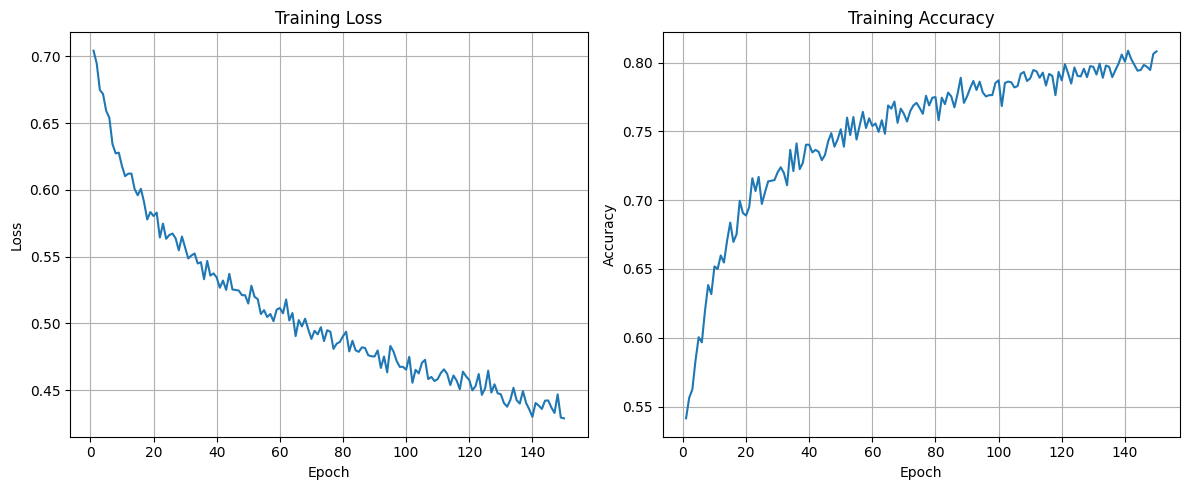

In [10]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1) 
plt.plot(range(1, epochs + 1), final_history["train_loss"])
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss')
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(range(1, epochs + 1), final_history["train_accuracy"])
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training Accuracy')
plt.grid(True)

plt.tight_layout()
plt.show()

## Testing

In [11]:
file_path = "processed_data/aggregated_processed_no_teams_embeddings_with_labels_test.pkl"
merged_df_test = pd.read_pickle(file_path)
X_test = np.vstack(merged_df_test["aggregated_embedding"].values)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32).to(device)

In [12]:
final_model.eval()
with torch.no_grad():
    logits = final_model(X_test_tensor).squeeze()  
    predictions = (torch.sigmoid(logits) >= 0.5).int().cpu().numpy()
    
final_df = pd.DataFrame({
    "ID": merged_df_test["ID"],
    "EventType": predictions  # Add predictions as EventType
})    

In [13]:
final_df.to_csv("predictions/bertweet_base_preprocessed_no_teams_predictions.csv", index=False)

# Same as Above- Different MLP

## Training

In [2]:
file_path = "processed_data/aggregated_processed_no_teams_embeddings_with_labels.pkl"
merged_df = pd.read_pickle(file_path)
X = np.vstack(merged_df["aggregated_embedding"].values)
y = merged_df["EventType"].values
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)
embedding_dim = X.shape[1]
batch_size = 64
k_folds = 5
skf = StratifiedKFold(n_splits=k_folds, shuffle=True, random_state=seed)
criterion = nn.BCEWithLogitsLoss()

In [5]:
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)

epochs = 500
fold_histories = []
fold_accuracies = []

for fold, (train_idx, val_idx) in enumerate(skf.split(X, y)):
    print(f'Fold {fold + 1}/{k_folds}')
    
    X_train_fold, X_val_fold = X[train_idx], X[val_idx]
    y_train_fold, y_val_fold = y[train_idx], y[val_idx]
    
    X_train_tensor = torch.tensor(X_train_fold, dtype=torch.float32)
    y_train_tensor = torch.tensor(y_train_fold, dtype=torch.float32)
    X_val_tensor = torch.tensor(X_val_fold, dtype=torch.float32)
    y_val_tensor = torch.tensor(y_val_fold, dtype=torch.float32)
    
    train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_dataset = TensorDataset(X_val_tensor, y_val_tensor)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
    
    model = BertweetMLP128Layer(embedding_dim).to(device)
    optimizer = optim.AdamW(model.parameters(), lr=1e-5, weight_decay=1e-5)
    
    history = train_and_validate_model(model, train_loader, val_loader, criterion, optimizer, device, epochs, seed, use_tqdm=False)
    fold_histories.append(history)
    
    val_accuracy = history['val_accuracy'][-1]
    fold_accuracies.append(val_accuracy)
    
    print(f'Fold {fold + 1} Validation Accuracy: {val_accuracy:.4f}')

Fold 1/5
Epoch 1/500
Training Loss: 0.7190, Accuracy: 0.5009
Validation Loss: 0.6949, Accuracy: 0.4603
Epoch 2/500
Training Loss: 0.7184, Accuracy: 0.5173
Validation Loss: 0.6958, Accuracy: 0.4533
Epoch 3/500
Training Loss: 0.7202, Accuracy: 0.5114
Validation Loss: 0.6934, Accuracy: 0.5047
Epoch 4/500
Training Loss: 0.7158, Accuracy: 0.5044
Validation Loss: 0.6887, Accuracy: 0.5397
Epoch 5/500
Training Loss: 0.7090, Accuracy: 0.5190
Validation Loss: 0.6873, Accuracy: 0.5561
Epoch 6/500
Training Loss: 0.7101, Accuracy: 0.5202
Validation Loss: 0.6843, Accuracy: 0.5864
Epoch 7/500
Training Loss: 0.6957, Accuracy: 0.5600
Validation Loss: 0.6831, Accuracy: 0.5724
Epoch 8/500
Training Loss: 0.6998, Accuracy: 0.5506
Validation Loss: 0.6820, Accuracy: 0.5864
Epoch 9/500
Training Loss: 0.7072, Accuracy: 0.5307
Validation Loss: 0.6804, Accuracy: 0.5911
Epoch 10/500
Training Loss: 0.7096, Accuracy: 0.5354
Validation Loss: 0.6767, Accuracy: 0.6121
Epoch 11/500
Training Loss: 0.6973, Accuracy: 0.53

In [6]:
average_accuracy = sum(fold_accuracies) / k_folds
print(f'Average Validation Accuracy: {average_accuracy:.4f}')

Average Validation Accuracy: 0.7717


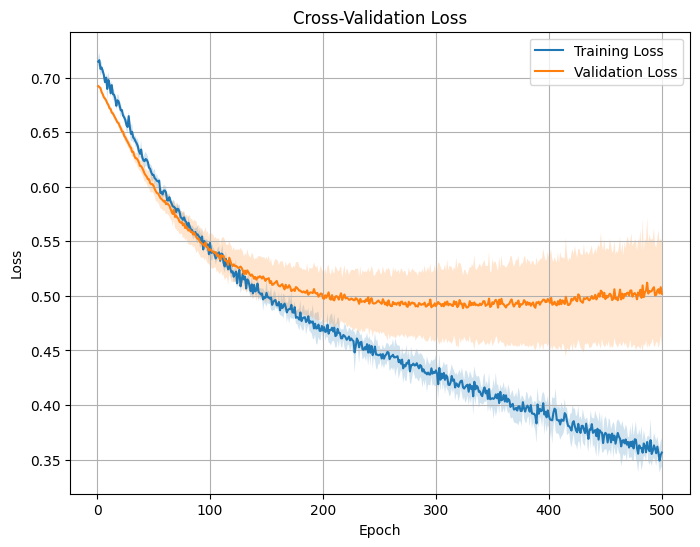

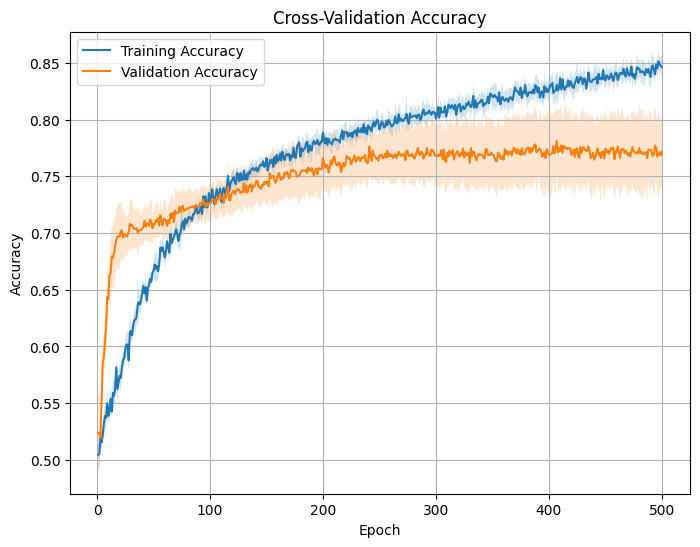

In [7]:
num_epochs = epochs
num_folds = k_folds

# Initialize arrays to store metrics
train_loss_all = np.zeros((num_folds, num_epochs))
val_loss_all = np.zeros((num_folds, num_epochs))
train_acc_all = np.zeros((num_folds, num_epochs))
val_acc_all = np.zeros((num_folds, num_epochs))

# Populate arrays with data from each fold
for i, history in enumerate(fold_histories):
    train_loss_all[i] = history['train_loss']
    val_loss_all[i] = history['val_loss']
    train_acc_all[i] = history['train_accuracy']
    val_acc_all[i] = history['val_accuracy']

# Compute mean and standard deviation
train_loss_mean = np.mean(train_loss_all, axis=0)
train_loss_std = np.std(train_loss_all, axis=0)
val_loss_mean = np.mean(val_loss_all, axis=0)
val_loss_std = np.std(val_loss_all, axis=0)

train_acc_mean = np.mean(train_acc_all, axis=0)
train_acc_std = np.std(train_acc_all, axis=0)
val_acc_mean = np.mean(val_acc_all, axis=0)
val_acc_std = np.std(val_acc_all, axis=0)

epochs_range = range(1, num_epochs + 1)

# Plot Loss
plt.figure(figsize=(8, 6))
plt.plot(epochs_range, train_loss_mean, label='Training Loss')
plt.fill_between(epochs_range, train_loss_mean - train_loss_std, train_loss_mean + train_loss_std, alpha=0.2)
plt.plot(epochs_range, val_loss_mean, label='Validation Loss')
plt.fill_between(epochs_range, val_loss_mean - val_loss_std, val_loss_mean + val_loss_std, alpha=0.2)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Cross-Validation Loss')
plt.legend()
plt.grid(True)
plt.show()

# Plot Accuracy
plt.figure(figsize=(8, 6))
plt.plot(epochs_range, train_acc_mean, label='Training Accuracy')
plt.fill_between(epochs_range, train_acc_mean - train_acc_std, train_acc_mean + train_acc_std, alpha=0.2)
plt.plot(epochs_range, val_acc_mean, label='Validation Accuracy')
plt.fill_between(epochs_range, val_acc_mean - val_acc_std, val_acc_mean + val_acc_std, alpha=0.2)
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Cross-Validation Accuracy')
plt.legend()
plt.grid(True)
plt.show()

250 epochs.

Epoch 1/250
Training Loss: 0.7256, Accuracy: 0.4951
Epoch 2/250
Training Loss: 0.7138, Accuracy: 0.5129
Epoch 3/250
Training Loss: 0.7195, Accuracy: 0.5105
Epoch 4/250
Training Loss: 0.7106, Accuracy: 0.5302
Epoch 5/250
Training Loss: 0.7147, Accuracy: 0.5185
Epoch 6/250
Training Loss: 0.7100, Accuracy: 0.5222
Epoch 7/250
Training Loss: 0.7112, Accuracy: 0.5236
Epoch 8/250
Training Loss: 0.7017, Accuracy: 0.5353
Epoch 9/250
Training Loss: 0.6941, Accuracy: 0.5433
Epoch 10/250
Training Loss: 0.6899, Accuracy: 0.5672
Epoch 11/250
Training Loss: 0.6895, Accuracy: 0.5531
Epoch 12/250
Training Loss: 0.6833, Accuracy: 0.5667
Epoch 13/250
Training Loss: 0.6969, Accuracy: 0.5428
Epoch 14/250
Training Loss: 0.6788, Accuracy: 0.5756
Epoch 15/250
Training Loss: 0.6829, Accuracy: 0.5840
Epoch 16/250
Training Loss: 0.6796, Accuracy: 0.5723
Epoch 17/250
Training Loss: 0.6752, Accuracy: 0.5793
Epoch 18/250
Training Loss: 0.6694, Accuracy: 0.5779
Epoch 19/250
Training Loss: 0.6761, Accuracy: 0.5779
Ep

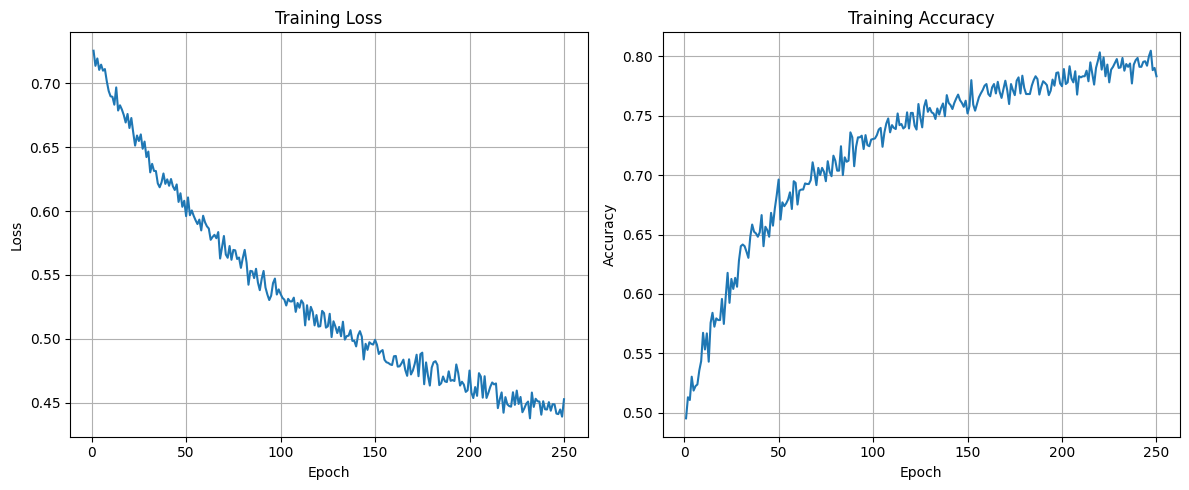

In [3]:
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)
epochs = 250
batch_size = 64
X_full_tensor = torch.tensor(X, dtype=torch.float32)
y_full_tensor = torch.tensor(y, dtype=torch.float32)
full_dataset = TensorDataset(X_full_tensor, y_full_tensor)
full_loader = DataLoader(full_dataset, batch_size=batch_size, shuffle=True)
final_model = BertweetMLP128Layer(embedding_dim).to(device)
final_optimizer = optim.AdamW(final_model.parameters(), lr=1e-5, weight_decay=1e-5)
final_history = train_and_validate_model(final_model, full_loader, None, criterion, final_optimizer, device, epochs, seed, use_tqdm=False)
torch.save(final_model.state_dict(), "models/bertweet_128layer_preprocessed_no_teams.pt")

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1) 
plt.plot(range(1, epochs + 1), final_history["train_loss"])
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss')
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(range(1, epochs + 1), final_history["train_accuracy"])
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training Accuracy')
plt.grid(True)

plt.tight_layout()
plt.show()

## Testing

In [4]:
file_path = "processed_data/aggregated_processed_no_teams_embeddings_with_labels_test.pkl"
merged_df_test = pd.read_pickle(file_path)
X_test = np.vstack(merged_df_test["aggregated_embedding"].values)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32).to(device)

final_model.eval()
with torch.no_grad():
    logits = final_model(X_test_tensor).squeeze()  
    predictions = (torch.sigmoid(logits) >= 0.5).int().cpu().numpy()
    
final_df = pd.DataFrame({
    "ID": merged_df_test["ID"],
    "EventType": predictions  # Add predictions as EventType
})

In [5]:
final_df.to_csv("predictions/bertweet_128layer_preprocessed_no_teams_predictions.csv", index=False)

# Preprocessed Data - No Teams, Similarity

## Training

In [3]:
file_path = "processed_data/similarity_aggregated_processed2_no_teams_embeddings_with_labels.pkl"
merged_df = pd.read_pickle(file_path)
X = np.vstack(merged_df["aggregated_embedding"].values)
y = merged_df["EventType"].values

In [5]:
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)
embedding_dim = X.shape[1]
batch_size = 64
k_folds = 5
skf = StratifiedKFold(n_splits=k_folds, shuffle=True, random_state=seed)
criterion = nn.BCEWithLogitsLoss()

In [6]:
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)

epochs = 500
fold_histories = []
fold_accuracies = []

for fold, (train_idx, val_idx) in enumerate(skf.split(X, y)):
    print(f'Fold {fold + 1}/{k_folds}')
    
    X_train_fold, X_val_fold = X[train_idx], X[val_idx]
    y_train_fold, y_val_fold = y[train_idx], y[val_idx]
    
    X_train_tensor = torch.tensor(X_train_fold, dtype=torch.float32)
    y_train_tensor = torch.tensor(y_train_fold, dtype=torch.float32)
    X_val_tensor = torch.tensor(X_val_fold, dtype=torch.float32)
    y_val_tensor = torch.tensor(y_val_fold, dtype=torch.float32)
    
    train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_dataset = TensorDataset(X_val_tensor, y_val_tensor)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
    
    model = BertweetBaseMLP(embedding_dim).to(device)
    optimizer = optim.AdamW(model.parameters(), lr=1e-5, weight_decay=1e-5)
    
    history = train_and_validate_model(model, train_loader, val_loader, criterion, optimizer, device, epochs, seed, use_tqdm=False)
    fold_histories.append(history)
    
    val_accuracy = history['val_accuracy'][-1]
    fold_accuracies.append(val_accuracy)
    
    print(f'Fold {fold + 1} Validation Accuracy: {val_accuracy:.4f}')

Fold 1/5
Epoch 1/500
Training Loss: 0.7116, Accuracy: 0.5190
Validation Loss: 0.6917, Accuracy: 0.5397
Epoch 2/500
Training Loss: 0.6952, Accuracy: 0.5430
Validation Loss: 0.6903, Accuracy: 0.6098
Epoch 3/500
Training Loss: 0.6713, Accuracy: 0.5810
Validation Loss: 0.6743, Accuracy: 0.6285
Epoch 4/500
Training Loss: 0.6728, Accuracy: 0.5769
Validation Loss: 0.6393, Accuracy: 0.6495
Epoch 5/500
Training Loss: 0.6679, Accuracy: 0.5828
Validation Loss: 0.6250, Accuracy: 0.6565
Epoch 6/500
Training Loss: 0.6469, Accuracy: 0.6121
Validation Loss: 0.6174, Accuracy: 0.6799
Epoch 7/500
Training Loss: 0.6525, Accuracy: 0.6156
Validation Loss: 0.6087, Accuracy: 0.6822
Epoch 8/500
Training Loss: 0.6322, Accuracy: 0.6197
Validation Loss: 0.6052, Accuracy: 0.6963
Epoch 9/500
Training Loss: 0.6366, Accuracy: 0.6226
Validation Loss: 0.5996, Accuracy: 0.6986
Epoch 10/500
Training Loss: 0.6171, Accuracy: 0.6618
Validation Loss: 0.5948, Accuracy: 0.7009
Epoch 11/500
Training Loss: 0.6084, Accuracy: 0.66

In [7]:
average_accuracy = sum(fold_accuracies) / k_folds
print(f'Average Validation Accuracy: {average_accuracy:.4f}')

Average Validation Accuracy: 0.7674


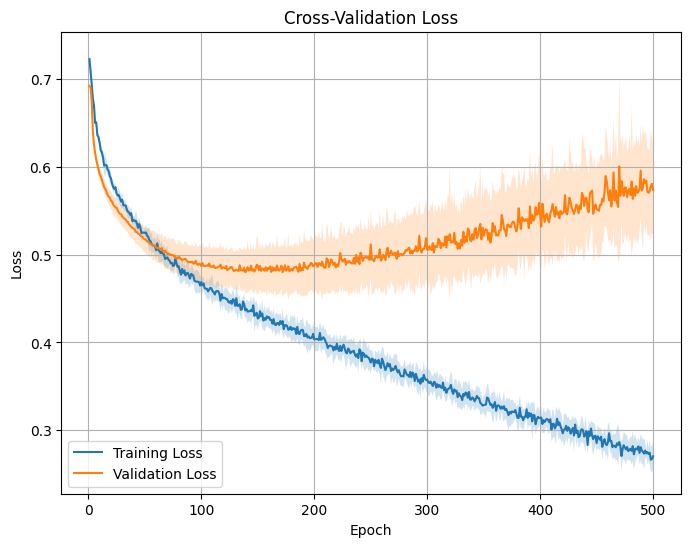

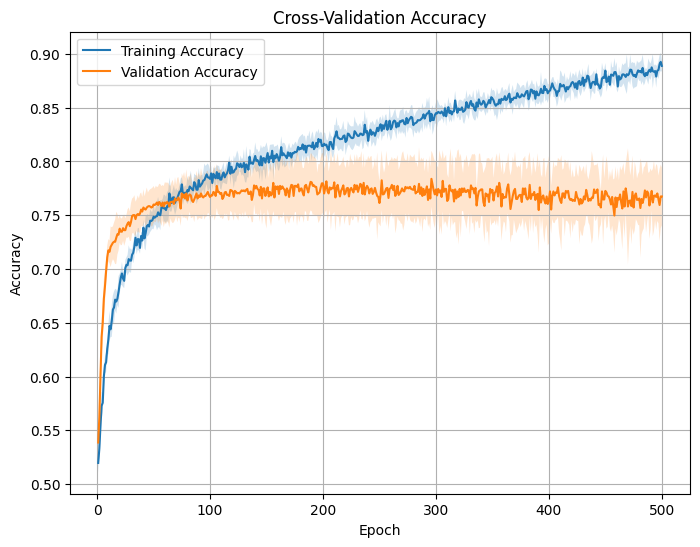

In [8]:
num_epochs = epochs
num_folds = k_folds

# Initialize arrays to store metrics
train_loss_all = np.zeros((num_folds, num_epochs))
val_loss_all = np.zeros((num_folds, num_epochs))
train_acc_all = np.zeros((num_folds, num_epochs))
val_acc_all = np.zeros((num_folds, num_epochs))

# Populate arrays with data from each fold
for i, history in enumerate(fold_histories):
    train_loss_all[i] = history['train_loss']
    val_loss_all[i] = history['val_loss']
    train_acc_all[i] = history['train_accuracy']
    val_acc_all[i] = history['val_accuracy']

# Compute mean and standard deviation
train_loss_mean = np.mean(train_loss_all, axis=0)
train_loss_std = np.std(train_loss_all, axis=0)
val_loss_mean = np.mean(val_loss_all, axis=0)
val_loss_std = np.std(val_loss_all, axis=0)

train_acc_mean = np.mean(train_acc_all, axis=0)
train_acc_std = np.std(train_acc_all, axis=0)
val_acc_mean = np.mean(val_acc_all, axis=0)
val_acc_std = np.std(val_acc_all, axis=0)

epochs_range = range(1, num_epochs + 1)

# Plot Loss
plt.figure(figsize=(8, 6))
plt.plot(epochs_range, train_loss_mean, label='Training Loss')
plt.fill_between(epochs_range, train_loss_mean - train_loss_std, train_loss_mean + train_loss_std, alpha=0.2)
plt.plot(epochs_range, val_loss_mean, label='Validation Loss')
plt.fill_between(epochs_range, val_loss_mean - val_loss_std, val_loss_mean + val_loss_std, alpha=0.2)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Cross-Validation Loss')
plt.legend()
plt.grid(True)
plt.show()

# Plot Accuracy
plt.figure(figsize=(8, 6))
plt.plot(epochs_range, train_acc_mean, label='Training Accuracy')
plt.fill_between(epochs_range, train_acc_mean - train_acc_std, train_acc_mean + train_acc_std, alpha=0.2)
plt.plot(epochs_range, val_acc_mean, label='Validation Accuracy')
plt.fill_between(epochs_range, val_acc_mean - val_acc_std, val_acc_mean + val_acc_std, alpha=0.2)
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Cross-Validation Accuracy')
plt.legend()
plt.grid(True)
plt.show()

So we do 150 epochs

In [9]:
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)
epochs = 150
batch_size = 64
X_full_tensor = torch.tensor(X, dtype=torch.float32)
y_full_tensor = torch.tensor(y, dtype=torch.float32)
full_dataset = TensorDataset(X_full_tensor, y_full_tensor)
full_loader = DataLoader(full_dataset, batch_size=batch_size, shuffle=True)
final_model = BertweetBaseMLP(embedding_dim).to(device)
final_optimizer = optim.AdamW(final_model.parameters(), lr=1e-5, weight_decay=1e-5)
final_history = train_and_validate_model(final_model, full_loader, None, criterion, final_optimizer, device, epochs, seed, use_tqdm=False)
torch.save(final_model.state_dict(), "models/bertweet_base_similarity_preprocessed2_no_teams.pt")

Epoch 1/150
Training Loss: 0.6990, Accuracy: 0.5438
Epoch 2/150
Training Loss: 0.6871, Accuracy: 0.5578
Epoch 3/150
Training Loss: 0.6710, Accuracy: 0.5732
Epoch 4/150
Training Loss: 0.6691, Accuracy: 0.5742
Epoch 5/150
Training Loss: 0.6512, Accuracy: 0.6013
Epoch 6/150
Training Loss: 0.6438, Accuracy: 0.5920
Epoch 7/150
Training Loss: 0.6307, Accuracy: 0.6275
Epoch 8/150
Training Loss: 0.6208, Accuracy: 0.6481
Epoch 9/150
Training Loss: 0.6211, Accuracy: 0.6425
Epoch 10/150
Training Loss: 0.6049, Accuracy: 0.6598
Epoch 11/150
Training Loss: 0.6003, Accuracy: 0.6589
Epoch 12/150
Training Loss: 0.5997, Accuracy: 0.6673
Epoch 13/150
Training Loss: 0.6011, Accuracy: 0.6631
Epoch 14/150
Training Loss: 0.5922, Accuracy: 0.6715
Epoch 15/150
Training Loss: 0.5879, Accuracy: 0.6907
Epoch 16/150
Training Loss: 0.5933, Accuracy: 0.6724
Epoch 17/150
Training Loss: 0.5811, Accuracy: 0.6977
Epoch 18/150
Training Loss: 0.5689, Accuracy: 0.7108
Epoch 19/150
Training Loss: 0.5732, Accuracy: 0.6996
Ep

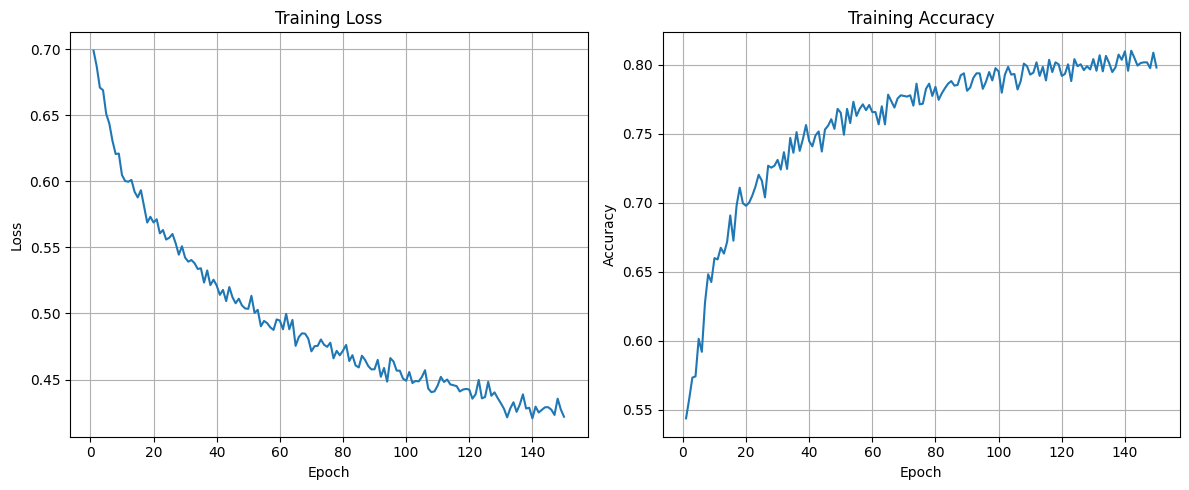

In [10]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1) 
plt.plot(range(1, epochs + 1), final_history["train_loss"])
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss')
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(range(1, epochs + 1), final_history["train_accuracy"])
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training Accuracy')
plt.grid(True)

plt.tight_layout()
plt.show()

## Testing

In [11]:
file_path = "processed_data/similarity_aggregated_processed2_no_teams_embeddings_with_labels_test.pkl"
merged_df_test = pd.read_pickle(file_path)
X_test = np.vstack(merged_df_test["aggregated_embedding"].values)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32).to(device)

In [12]:
final_model.eval()
with torch.no_grad():
    logits = final_model(X_test_tensor).squeeze()  
    predictions = (torch.sigmoid(logits) >= 0.5).int().cpu().numpy()
    
final_df = pd.DataFrame({
    "ID": merged_df_test["ID"],
    "EventType": predictions  # Add predictions as EventType
})    

In [13]:
final_df.to_csv("predictions/bertweet_base_similarity_preprocessed2_no_teams_predictions.csv", index=False)